# Transformer for Multimodal Stock Forecasting
Implementation notebook for *Adaptive Portfolio Management in Volatile Markets with Multiplex Attention Transformers and Deep Reinforcement Learning*.

**For obtaining custom train/validate/test dataset csv files, please directly run the respective notebooks titled "{category}_data.ipynb" in the Github repo.
The csv files used to train our model are included in the Github repo.**

Code for **PyTorch** implementation of the Transformer proposed in our paper, trained to predict multi-step stock price trajectories from:
1. **Technical indicators** (OHLCV/technical-derived)
2. **News-sentiment embeddings** (majority voting on FinBERT, VADER, and the Loughran-McDonald lexicon)
3. **Macroeconomic features** (derived from market and sector)

The model outputs \(H\)-step forecasts that later serve as inputs to the downstream RL trading agent.

We implemented two Transformer models, the TFT Transformer Model and Vanilla Transformer model.




In [1]:
# install dependencies
!pip install -U torch torchvision torchaudio --quiet
!pip install -U transformers datasets peft --quiet
!pip install -U wandb --quiet
!pip install pytorch_lightning --quiet
!pip install pytorch_forecasting --quiet
!pip install darts --quiet
!pip install pandas_market_calendars --quiet
!pip install peft --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.2/865.2 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201

In [2]:
# import packages and define constants
import darts
import math, os, random, json, itertools, warnings, datetime as dt, typing as typ
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
import wandb
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Running on', device)

# some hyperparameters
WINDOW_SIZE = 30  # T
HORIZON_SIZE = 5  # H
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-2
ALPHA         = 1.0      # weight for MSE vs BCE for vanilla Transformer
GRAD_CLIP     = 2.0

# feature dimensions
TECH_DIM = 10
SENT_DIM = 1
MACRO_DIM = 3


Running on cuda


# Optional: wandb logging


In [3]:
# # uncomment to use
# init wandb
# wandb_api = ""
# wandb.login(key=wandb_api)
# wandb.init(
#     project="transformer price forecast",
#     config={
#         "window": WINDOW_SIZE,
#         "horizon": HORIZON_SIZE,
#         "lr": 1e-4,
#     }
# )

## add wandb logging as necessary

# Data Processing


In [3]:
# define data processor classes

import pandas as pd, numpy as np
import pandas as pd, numpy as np, torch
from torch.utils.data import Dataset, DataLoader


def load_tensor(csv_path: str, feature_cols: list[str],
                tickers=None, dates=None):
    df = pd.read_csv(csv_path, parse_dates=['date'])

    if tickers is None: tickers = sorted(df['ticker'].unique())
    if dates   is None: dates   = sorted(df['date'].unique())

    df = (df.query('ticker in @tickers and date in @dates')
            .sort_values(['date', 'ticker']))

    mats = []
    for feat in feature_cols:
        mat = (df.pivot(index='date', columns='ticker', values=feat)
                 .reindex(index=dates, columns=tickers)
                 .astype('float32')
                 .fillna(0.0)   # replace missing with 0, try avoiding nan
                 .values)
        mats.append(mat[..., None])

    return np.concatenate(mats, axis=2), tickers, dates

class MultiCSVWindowDataset(Dataset):
    """
    Each sample = (x_stock, x_sent, x_macro, y)
    Shapes:
      x_* : [window, F]   (one ticker, consecutive dates)
      y   : [horizon, 1]  (open/close/high/low for next horizon days)
    """
    def __init__(self, npz_path: str, window: int = WINDOW_SIZE, horizon: int = HORIZON_SIZE):
        data = np.load(npz_path)
        self.stock  = data['tech']    # [D, N, F1]
        self.sent   = data['sent']    # [D, N, F2]
        self.macro  = data['macro']   # [D, N, F3]
        self.labels = data['price']   # [D, N, 1]

        self.T = window
        self.H = horizon
        self.D = self.stock.shape[0] - window - horizon
        self.N = self.stock.shape[1]

    def __len__(self):
        return self.D * self.N            # all (ticker, start‑time) pairs

    def __getitem__(self, idx):
        t0 = idx % self.D                 # time start
        k  = idx // self.D                # ticker index

        x_stock = self.stock [t0:t0+self.T, k, :]
        x_sent  = self.sent  [t0:t0+self.T, k, :]
        x_macro = self.macro[t0:t0+self.T, k, :]
        y = self.labels[t0+self.T:t0+self.T+self.H, k, :]   # horizon×4

        # previous day's true close:
        # this is for calculating accuracy only
        prev_close = self.labels[t0+self.T-1, k, 0]     # scalar

        # historical closes
        hist_close = self.labels[t0 : t0+self.T, k, 0]   # [T]

        return (torch.tensor(x_stock),
                torch.tensor(x_sent),
                torch.tensor(x_macro),
                torch.tensor(y),
                torch.tensor(prev_close),
                torch.tensor(hist_close))


# feature scaling (min‑max to 0‑1)
class MinMaxScaler:
    def __init__(self, feature_range=(0, 1)):
        self.min_ = None
        self.max_ = None
        self.data_min_ = None
        self.data_max_ = None
        self.feature_range = feature_range

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.data_min_ = X.min(axis=0)
        self.data_max_ = X.max(axis=0)
        self.min_ = self.feature_range[0]
        self.max_ = self.feature_range[1]
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        scale = (self.max_ - self.min_) / (self.data_max_ - self.data_min_)
        X_scaled = self.min_ + (X - self.data_min_) * scale
        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def inverse_transform(self, X_scaled):
        X_scaled = np.asarray(X_scaled, dtype=float)
        scale = (self.max_ - self.min_) / (self.data_max_ - self.data_min_)
        X_original = self.data_min_ + (X_scaled - self.min_) / scale
        return X_original


class DataPreprocessor():
    def __init__(self):
        self.scalers = {"tech": [], "sent": [], "macro": [], "label": []}

    def add_scalers(self, df_type: str, new_scalers: list):
        if df_type in self.scalers:
            self.scalers[df_type].extend(new_scalers)
        else:
            raise KeyError("dataframe type not supported!")

    def fit_transform(self, df_type: str, X):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_scaled = np.empty_like(X)
        days, stocks, features = X.shape

        for i in range(features):
            feature_data = X[:, :, i].reshape(-1, 1)  # (days * stocks, 1)
            X_scaled_feature = self.scalers[df_type][i].fit_transform(feature_data)
            X_scaled[:, :, i] = X_scaled_feature.reshape(days, stocks)

        return X_scaled

    def transform(self, df_type: str, X):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_scaled = np.empty_like(X)
        days, stocks, features = X.shape

        for i in range(features):
            feature_data = X[:, :, i].reshape(-1, 1)
            X_scaled_feature = self.scalers[df_type][i].transform(feature_data)
            X_scaled[:, :, i] = X_scaled_feature.reshape(days, stocks)

        return X_scaled

    def inverse_transform(self, df_type: str, X_scaled):
        """
        X: numpy array of shape (days, stocks, features)
        """
        X_orig = np.empty_like(X_scaled)
        days, stocks, features = X_scaled.shape

        for i in range(features):
            feature_data = X_scaled[:, :, i].reshape(-1, 1)
            X_orig_feature = self.scalers[df_type][i].inverse_transform(feature_data)
            X_orig[:, :, i] = X_orig_feature.reshape(days, stocks)

        return X_orig

    def process(self, tech_csv: str, sent_csv: str,
                           macro_csv: str, label_csv: str,
                           train_mode: bool, dataset_out_path: str):
        """
        Preprocesses tech, sent, macro, and label datasets.

        Args:
            tech_csv, sent_csv, macro_csv, label_csv: csv file paths
            train_mode: True for scalers to fit-transform, False for scalers to transform only
            dataset_out_path: file path to save output MultiCSVWindowDataset

        Returns:
            dataset: a MultiCSVWindowDataset
            loader: a DataLoader
        """

        tech_cols = ['volume','macd','boll_ub','boll_lb','rsi_30','cci_30',
                      'dx_30','close_30_sma','close_60_sma','vix', 'close',
                     'open','high', 'low']
        sent_cols  = ['sentiment']
        macro_cols = ['fedfunds','sp500','sector']
        label_cols = ['close']

        # build aligned tensors
        tech, tickers, dates  = load_tensor(tech_csv,  tech_cols) # tech.shape = (# dates, # tickers, # features)
        sent, _, _ = load_tensor(sent_csv,  sent_cols,  tickers, dates)
        macro, _, _  = load_tensor(macro_csv, macro_cols, tickers, dates)
        # print(macro.shape, type(macro), macro)

        #  build 4‑price cube (Date × Ticker)
        lbl_df = pd.read_csv(label_csv, parse_dates=['date'])
        lbl_df = (
            lbl_df.query('ticker in @tickers and date in @dates')
                  .sort_values(['date', 'ticker'])
        )

        label_mats = []
        for col in label_cols:         # ['close']
            mat = (lbl_df.pivot(index='date', columns='ticker', values=col)
                          .reindex(index=dates, columns=tickers)     # enforce exact order
                          .astype('float32')
                          .values)                                   # (D, N)
            label_mats.append(mat[..., None])                        # add 1‑len feature axis

        label = np.concatenate(label_mats, axis=2)         # (D, N, 1)
        # print(label.shape, type(label), label)
        self.add_scalers("tech", [MinMaxScaler() for col in tech_cols])
        self.add_scalers("sent", [MinMaxScaler() for col in sent_cols])
        self.add_scalers("macro", [MinMaxScaler() for col in macro_cols])
        self.add_scalers("label", [MinMaxScaler() for col in label_cols])
        if train_mode:
            tech_scaled = self.fit_transform(df_type = "tech", X = tech)
            sent_scaled = self.fit_transform(df_type = "sent", X = sent)
            macro_scaled = self.fit_transform(df_type = "macro", X = macro)
            label_scaled = self.fit_transform(df_type = "label", X = label)
        else:
            tech_scaled = self.transform(df_type = "tech", X = tech)
            sent_scaled = self.transform(df_type = "sent", X = sent)
            macro_scaled = self.transform(df_type = "macro", X = macro)
            label_scaled = self.transform(df_type = "label", X = label)
        # print(label_scaled.shape, label_scaled)


        np.savez_compressed(
            dataset_out_path,
            tech=tech_scaled, sent=sent_scaled,
            macro=macro_scaled, price=label)


        dataset = MultiCSVWindowDataset(dataset_out_path, window=WINDOW_SIZE, horizon=HORIZON_SIZE)
        loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
        return dataset, loader




## Get Train, Validation and Test Data

In [4]:
# Remember to upload the csv files locally

# get train data
data_preprocessor = DataPreprocessor()
dataset, loader = data_preprocessor.process(tech_csv="train_stock.csv",
                                            sent_csv="train_sentiment.csv",
                                            macro_csv="train_macro.csv",
                                            label_csv="train_stock.csv",
                                            train_mode=True,
                                            dataset_out_path="aligned_data_train.npz")

# right after building train_dataset, check shape
x_s, x_se, x_m, y, close, hist_close = dataset[0]
print(y)
print(close)
print("First train window shapes:", x_s.shape, x_se.shape, x_m.shape, y.shape)
print(" First target (raw):", data_preprocessor.inverse_transform("label", y.unsqueeze(0)).round())
print(" First features peek:", x_s[-1, :3].round())  # last time‐step stock features


# get val data
dataset, loader = data_preprocessor.process(tech_csv="val_stock.csv",
                                            sent_csv="val_sentiment.csv",
                                            macro_csv="val_macro.csv",
                                            label_csv="val_stock.csv",
                                            train_mode=False,
                                            dataset_out_path="aligned_data_val.npz")


# get test data
dataset, loader = data_preprocessor.process(tech_csv="test_stock.csv",
                                            sent_csv="test_sentiment.csv",
                                            macro_csv="test_macro.csv",
                                            label_csv="test_stock.csv",
                                            train_mode=False,
                                            dataset_out_path="aligned_data_test.npz")






tensor([[2.8447],
        [2.8399],
        [2.7277],
        [2.7445],
        [2.6166]])
tensor(2.9841)
First train window shapes: torch.Size([30, 14]) torch.Size([30, 1]) torch.Size([30, 3]) torch.Size([5, 1])
 First target (raw): [[[1220.]
  [1218.]
  [1170.]
  [1177.]
  [1122.]]]
 First features peek: tensor([0., 1., 0.])


# TFT Forecasting
TFT forecasting with Darts for multi-stock data using covariates


In [5]:

# get data and constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from darts import TimeSeries
from darts.models import TFTModel
from darts.utils.likelihood_models import QuantileRegression
from darts.dataprocessing.transformers import Scaler
import warnings
import pandas_market_calendars as mcal

warnings.filterwarnings('ignore')

# hyperparameters and data paths
NPZ_TRAIN         = 'aligned_data_train.npz'
NPZ_VAL           = 'aligned_data_val.npz'
NPZ_TEST          = 'aligned_data_test.npz'  # your test file
INPUT_CHUNK_LENGTH = 30
FORECAST_HORIZON   = 1
BATCH_SIZE         = 32
N_EPOCHS           = 100
RANDOM_STATE       = 42

# load data
train_npz = np.load(NPZ_TRAIN)
val_npz   = np.load(NPZ_VAL)
test_npz  = np.load(NPZ_TEST)

days_train, num_tickers, _ = train_npz['price'].shape
days_val                   =   val_npz['price'].shape[0]
days_test                  =  test_npz['price'].shape[0]

# market calendar
nyse = mcal.get_calendar("NYSE")
schedule_train = nyse.schedule(
    start_date="2009-01-01",
    end_date="2020-06-30"
)
schedule_val   = nyse.schedule(
    start_date="2020-07-01",
    end_date="2024-03-31"
)
schedule_test  = nyse.schedule(
    start_date="2024-04-01",
    end_date="2025-03-31"
)

dates_train = schedule_train.index
dates_val   = schedule_val.index
dates_test  = schedule_test.index

# sanity check lengths
assert len(dates_train) == days_train
assert len(dates_val)   == days_val
assert len(dates_test)  == days_test

# prepare column names for covariates
tech_n  = train_npz['tech'].shape[2]
sent_n  = train_npz['sent'].shape[2]
macro_n = train_npz['macro'].shape[2]

cov_cols = (
    [f"tech_{i}"  for i in range(tech_n)]
  + [f"sent_{i}"  for i in range(sent_n)]
  + [f"macro_{i}" for i in range(macro_n)]
)

# business-day freq from NYSE
from pandas.tseries.offsets import CustomBusinessDay
holidays = nyse.holidays().holidays
freq     = CustomBusinessDay(holidays=holidays)

# Build the four lists for train/val/test
train_target_list   = []
train_past_cov_list = []
val_target_list     = []
val_past_cov_list   = []
test_target_list    = []
test_past_cov_list  = []

for t in range(num_tickers):
    # TRAIN price
    price_tr = train_npz['price'][:, t, 0]
    ts_tr    = TimeSeries.from_times_and_values(
                   dates_train, price_tr,
                   freq=freq,
                   fill_missing_dates=False
               )
    train_target_list.append(ts_tr)

    # TRAIN covariates
    cov_tr = np.concatenate([
        train_npz['tech'][:,  t, :],
        train_npz['sent'][:,  t, :],
        train_npz['macro'][:, t, :]
    ], axis=1)
    df_cov_tr = pd.DataFrame(cov_tr, index=dates_train, columns=cov_cols)
    ts_cov_tr = TimeSeries.from_dataframe(
                    df_cov_tr, freq=freq, fill_missing_dates=False
                )
    train_past_cov_list.append(ts_cov_tr)

    # VAL price
    price_v  = val_npz['price'][:, t, 0]
    ts_val   = TimeSeries.from_times_and_values(
                   dates_val, price_v,
                   freq=freq,
                   fill_missing_dates=False
               )
    val_target_list.append(ts_val)

    # VAL covariates
    cov_v = np.concatenate([
        val_npz['tech'][:,  t, :],
        val_npz['sent'][:,  t, :],
        val_npz['macro'][:, t, :]
    ], axis=1)
    df_cov_v = pd.DataFrame(cov_v, index=dates_val, columns=cov_cols)
    ts_cov_v = TimeSeries.from_dataframe(
                   df_cov_v, freq=freq, fill_missing_dates=False
               )
    val_past_cov_list.append(ts_cov_v)

    # TEST price
    price_te = test_npz['price'][:, t, 0]
    ts_te    = TimeSeries.from_times_and_values(
                   dates_test, price_te,
                   freq=freq,
                   fill_missing_dates=False
               )
    test_target_list.append(ts_te)

    # TEST covariates
    cov_te = np.concatenate([
        test_npz['tech'][:,  t, :],
        test_npz['sent'][:,  t, :],
        test_npz['macro'][:, t, :]
    ], axis=1)
    df_cov_te = pd.DataFrame(cov_te, index=dates_test, columns=cov_cols)
    ts_cov_te = TimeSeries.from_dataframe(
                    df_cov_te, freq=freq, fill_missing_dates=False
                )
    test_past_cov_list.append(ts_cov_te)





## Optional: early stopping

In [6]:
# add early stopping
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

# define stopper
my_stopper = EarlyStopping(
    monitor="val_loss",    # the metric to watch
    patience=15,           # wait this many epochs with no improvement
    min_delta=0.001,       # only count an “improvement” if loss drops ≥ this
    mode="min"             # we want val_loss to go down
)



## Training Loop

In [7]:
# instantiate and fit TFTModel

from torch.nn import L1Loss, SmoothL1Loss


# quantile regression: experiment with different quantiles
# not needed for SmoothL1Loss
#quantiles = np.arange(0.01, 1.0, 0.01).tolist()
quantiles = [0.01, 0.05, 0.1, 0.15, 0.2,0.25, 0.3, 0.4, 0.5,
             0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.99,]
#quantiles = [0.25, 0.5, 0.75]

likelihood = QuantileRegression(quantiles=quantiles)
model = TFTModel(
    input_chunk_length=INPUT_CHUNK_LENGTH,
    output_chunk_length=FORECAST_HORIZON,
    hidden_size=64,
    lstm_layers=2,
    num_attention_heads=4,
    dropout=0.2,
    batch_size=BATCH_SIZE,
    n_epochs=100,
    add_relative_index=True,
    add_encoders=None,
    #likelihood=likelihood,
    likelihood=None,
    random_state=RANDOM_STATE,
    use_static_covariates=False,
    force_reset=True,
    #loss_fn=L1Loss(),
    loss_fn=SmoothL1Loss(beta=1.0),
    pl_trainer_kwargs={
        'accelerator': 'gpu',
        'gradient_clip_val': 0.1,
        'enable_progress_bar': True,
        'max_epochs': N_EPOCHS,
        'check_val_every_n_epoch': 1,
        'log_every_n_steps': 10,
        'logger': True,
        'callbacks': [my_stopper],
    }
)

model.fit(
    series=train_target_list,
    past_covariates=train_past_cov_list,
    val_series=val_target_list,
    val_past_covariates=val_past_cov_list,
    verbose=True
)



INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | SmoothL1Loss                     | 0      | train
1  | train_criterion                   | SmoothL1Loss                     | 0      | train
2  | val_criterion                     | SmoothL1Loss                     | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection               

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, loss_fn=SmoothL1Loss(), likelihood=None, norm_type=LayerNorm, use_static_covariates=False, input_chunk_length=30, output_chunk_length=1, batch_size=32, n_epochs=100, add_encoders=None, random_state=42, force_reset=True, pl_trainer_kwargs={'accelerator': 'gpu', 'gradient_clip_val': 0.1, 'enable_progress_bar': True, 'max_epochs': 100, 'check_val_every_n_epoch': 1, 'log_every_n_steps': 10, 'logger': True, 'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x7f8f503c3950>]})

## Visualize Data and Print Metrics

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


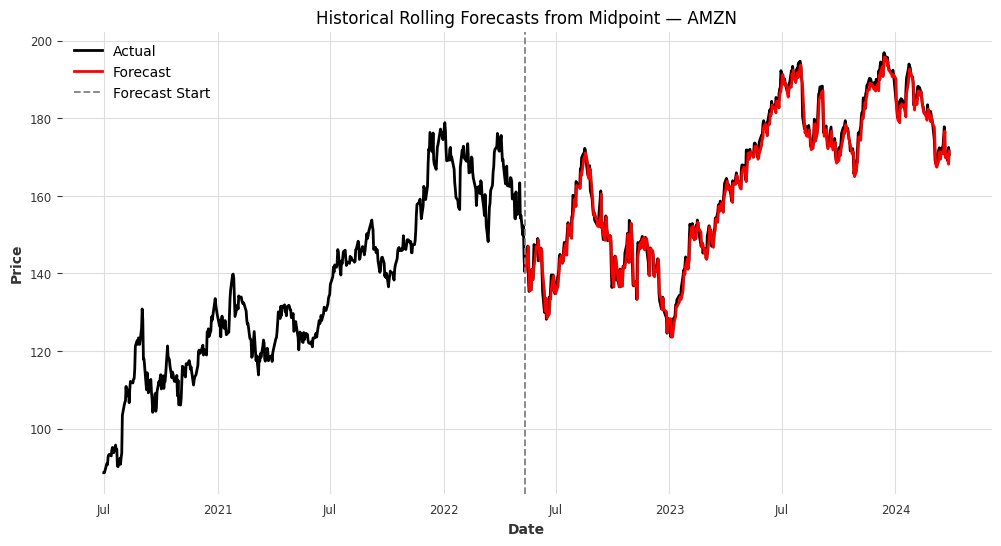

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for AMZN: MAPE=1.31%, SMAPE=1.32%, MAE=2.0932, MSE=7.47, R²=0.980
Directional Accuracy for AMZN: 49.79%



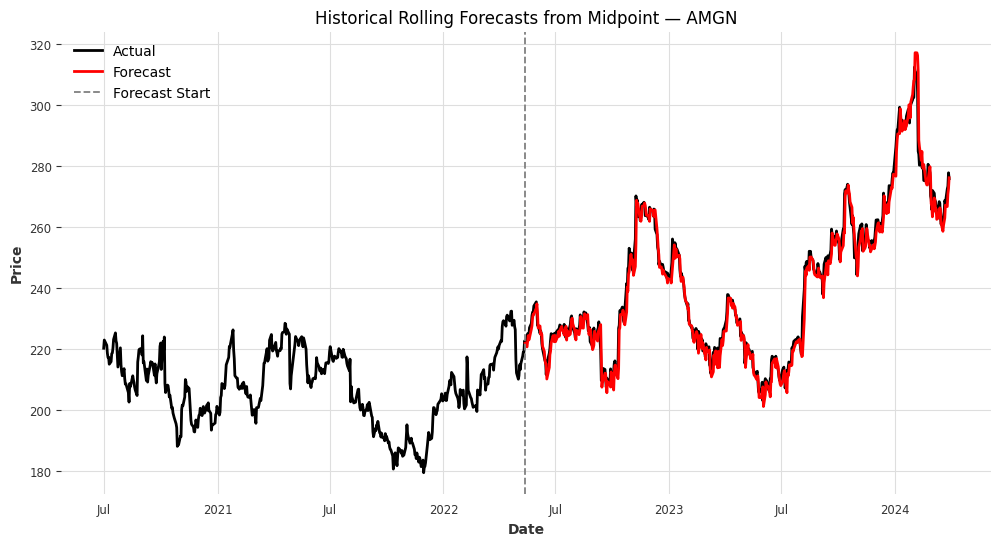

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for AMGN: MAPE=1.08%, SMAPE=1.08%, MAE=2.6266, MSE=13.54, R²=0.977
Directional Accuracy for AMGN: 50.85%



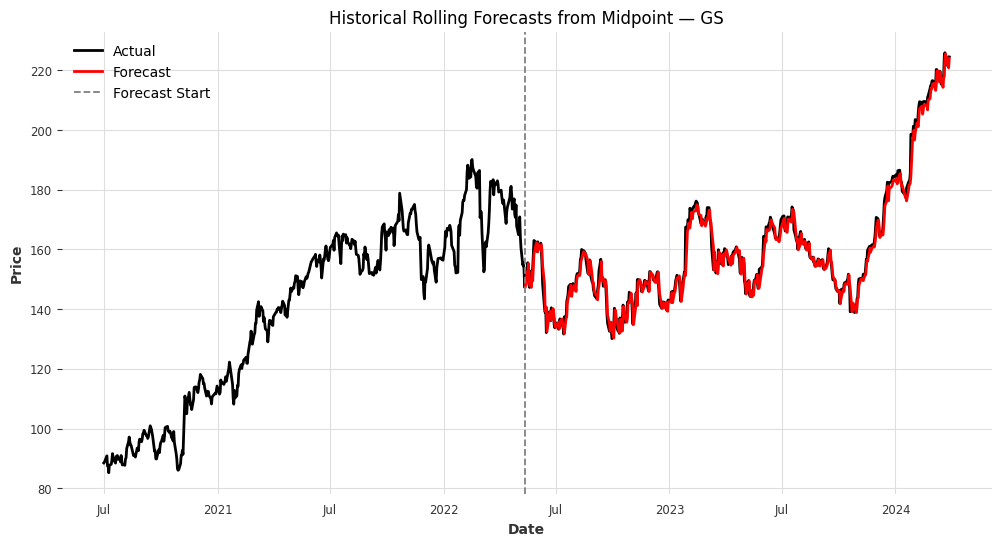

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for GS: MAPE=1.35%, SMAPE=1.36%, MAE=2.1412, MSE=8.02, R²=0.982
Directional Accuracy for GS: 53.40%



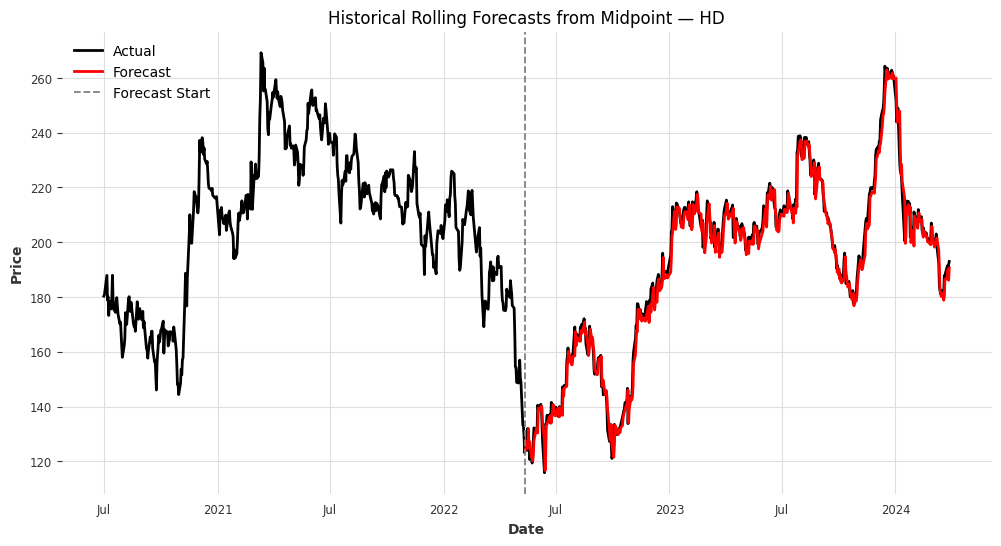

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for HD: MAPE=1.76%, SMAPE=1.76%, MAE=3.2410, MSE=18.58, R²=0.983
Directional Accuracy for HD: 51.28%



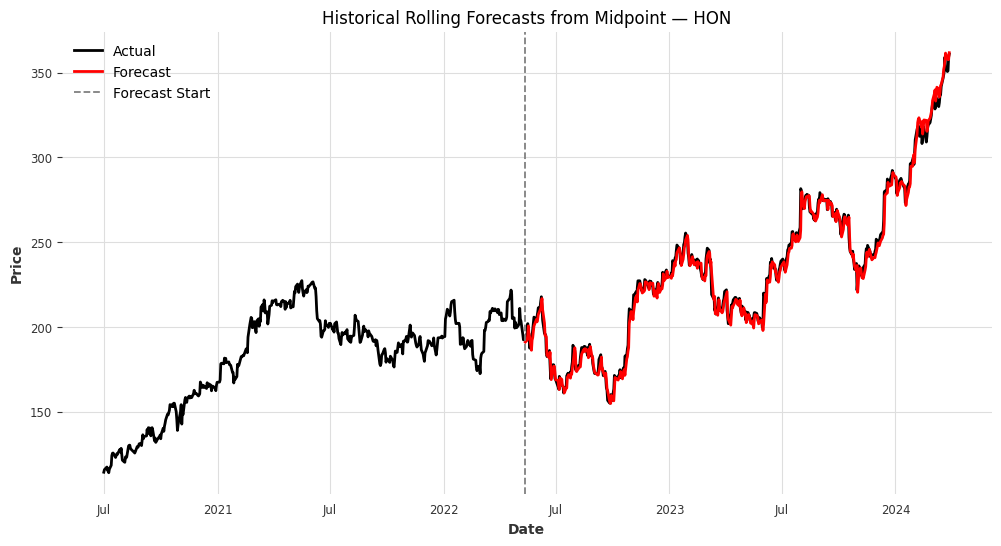

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for HON: MAPE=1.50%, SMAPE=1.51%, MAE=3.4440, MSE=21.08, R²=0.990
Directional Accuracy for HON: 55.11%



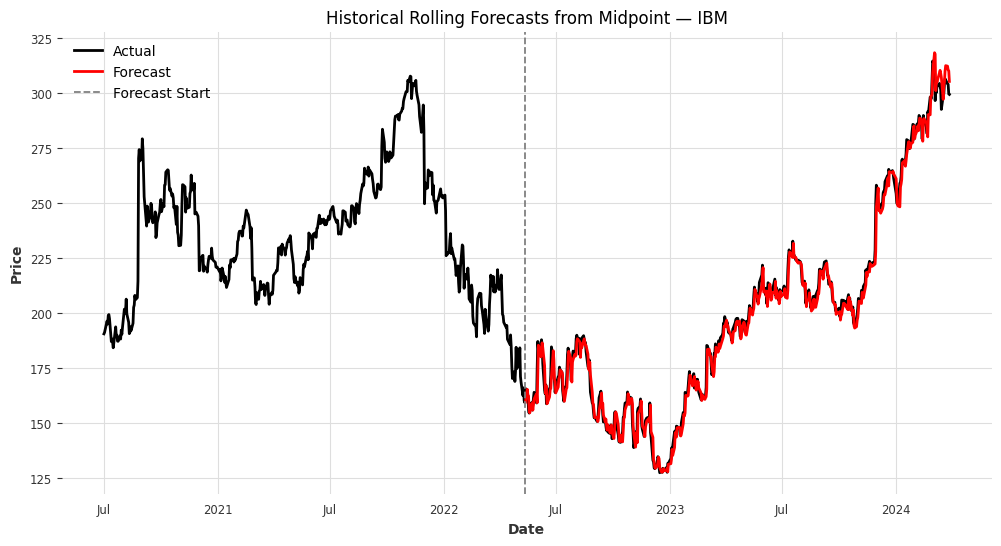

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for IBM: MAPE=1.76%, SMAPE=1.77%, MAE=3.3971, MSE=20.63, R²=0.990
Directional Accuracy for IBM: 54.89%



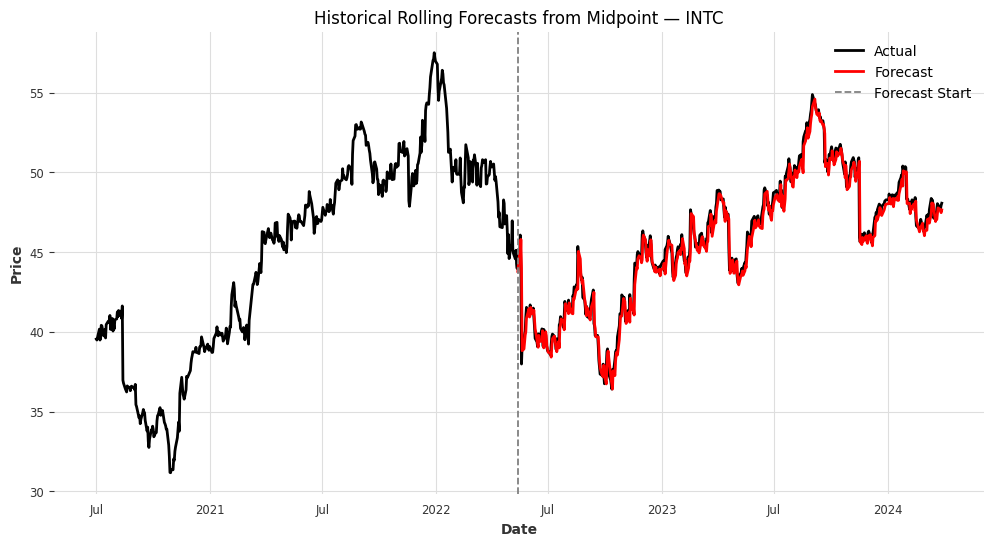

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for INTC: MAPE=1.08%, SMAPE=1.08%, MAE=0.4875, MSE=0.50, R²=0.970
Directional Accuracy for INTC: 50.85%



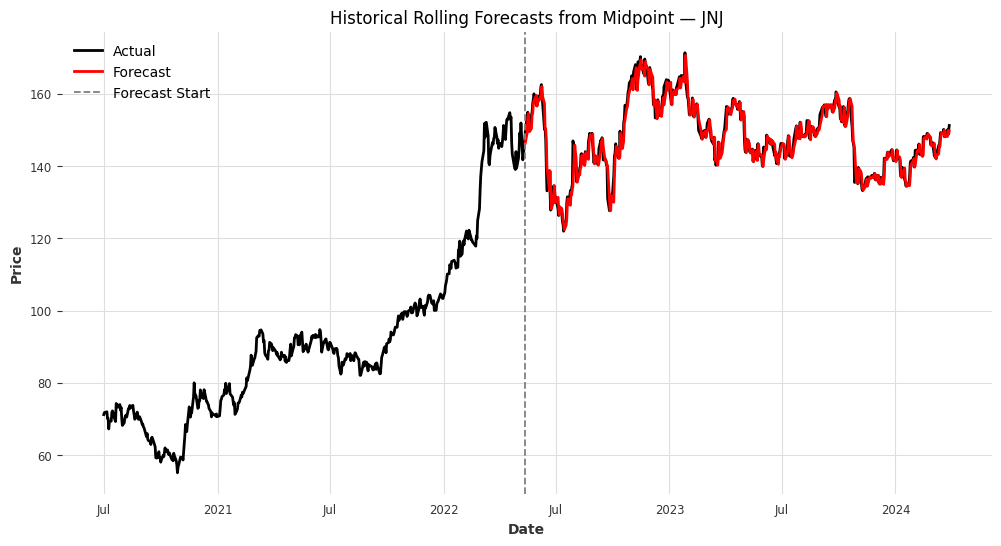

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for JNJ: MAPE=1.24%, SMAPE=1.24%, MAE=1.8285, MSE=6.06, R²=0.934
Directional Accuracy for JNJ: 50.00%



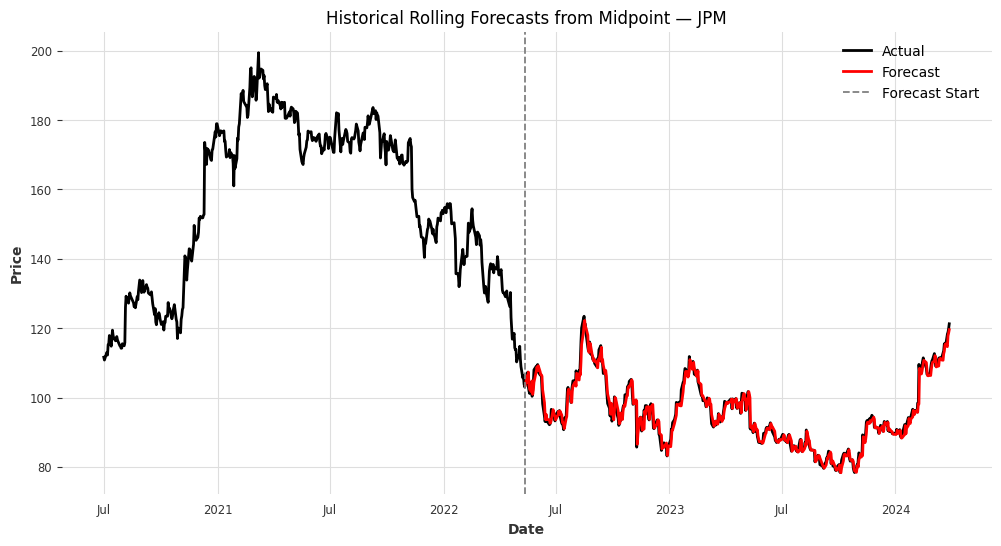

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for JPM: MAPE=1.47%, SMAPE=1.47%, MAE=1.4221, MSE=3.94, R²=0.958
Directional Accuracy for JPM: 51.70%



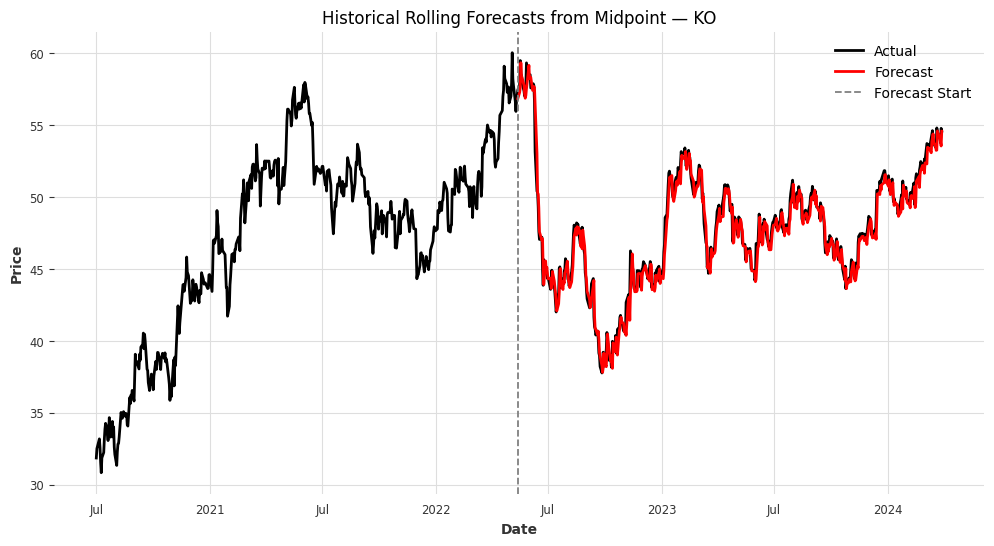

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for KO: MAPE=1.25%, SMAPE=1.26%, MAE=0.5931, MSE=0.60, R²=0.965
Directional Accuracy for KO: 53.83%



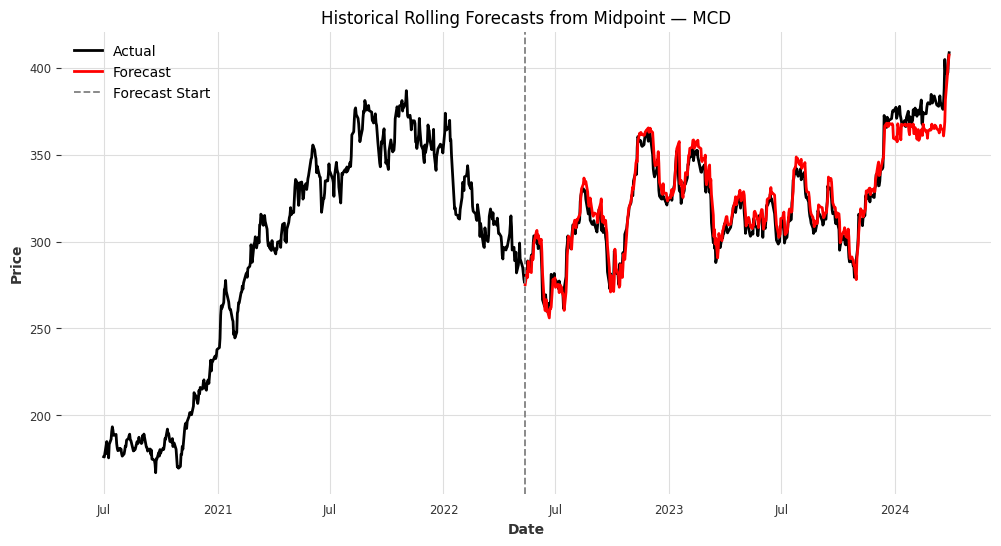

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MCD: MAPE=1.83%, SMAPE=1.83%, MAE=5.9944, MSE=60.70, R²=0.935
Directional Accuracy for MCD: 54.89%



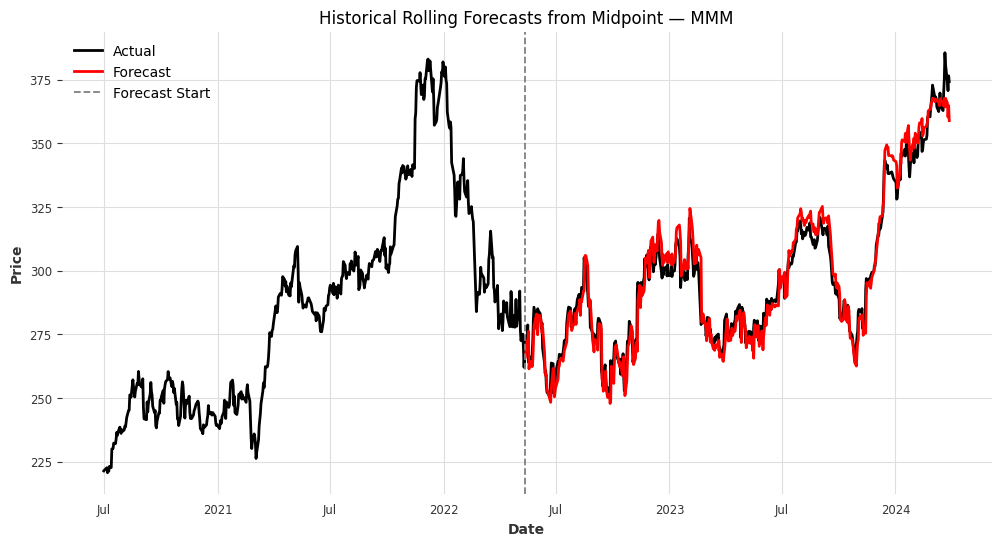

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MMM: MAPE=1.54%, SMAPE=1.53%, MAE=4.5654, MSE=34.09, R²=0.960
Directional Accuracy for MMM: 51.70%



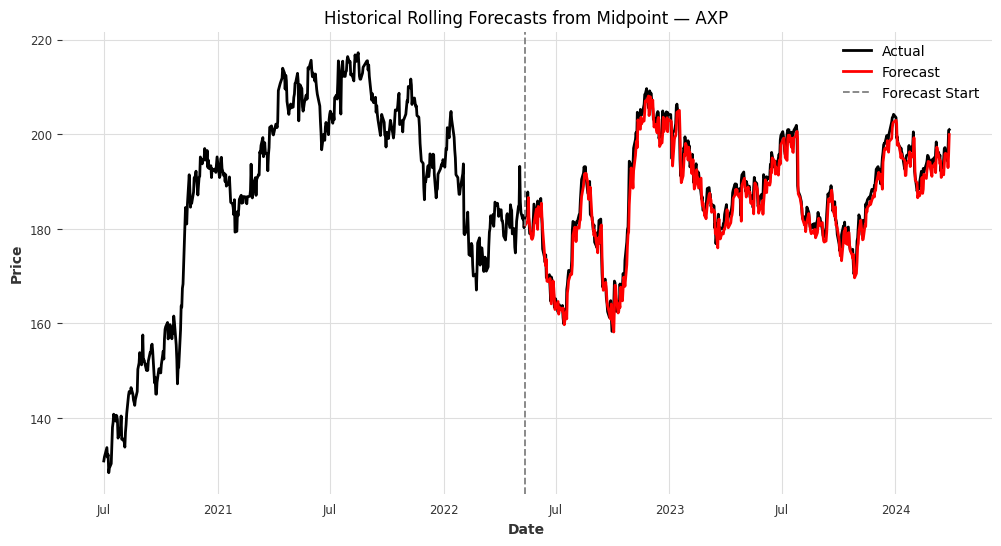

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for AXP: MAPE=1.12%, SMAPE=1.13%, MAE=2.0964, MSE=6.91, R²=0.945
Directional Accuracy for AXP: 49.36%



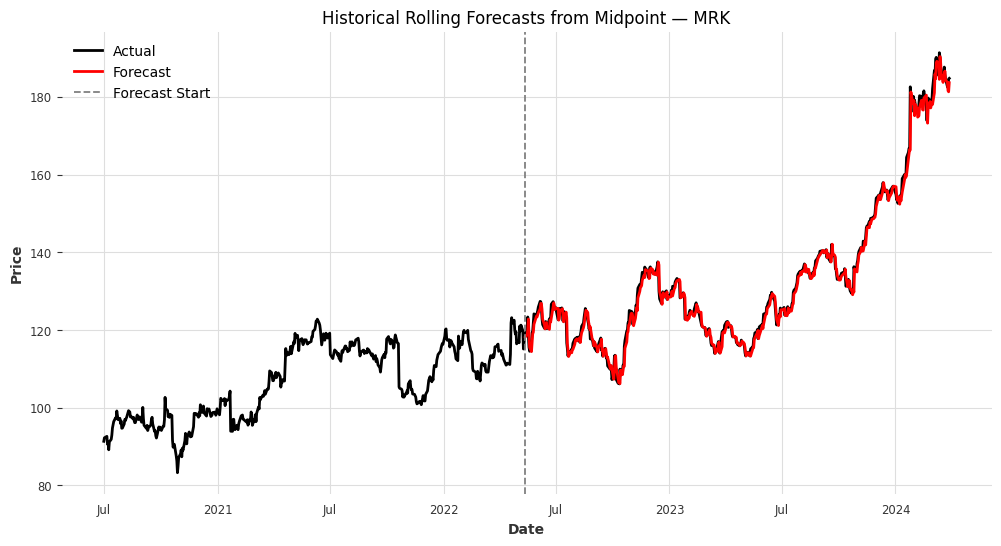

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MRK: MAPE=0.96%, SMAPE=0.97%, MAE=1.2915, MSE=3.37, R²=0.991
Directional Accuracy for MRK: 52.98%



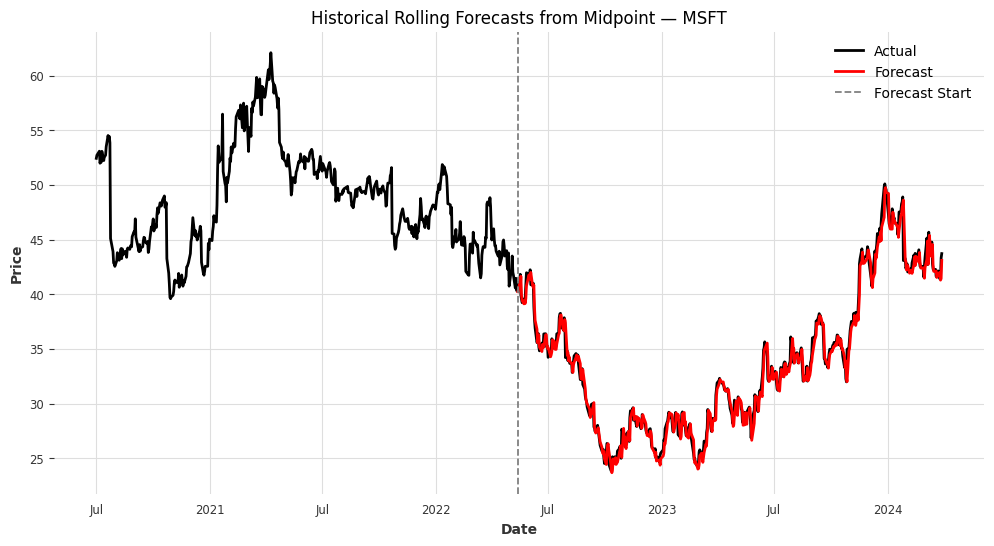

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for MSFT: MAPE=1.90%, SMAPE=1.90%, MAE=0.6379, MSE=0.74, R²=0.982
Directional Accuracy for MSFT: 54.26%



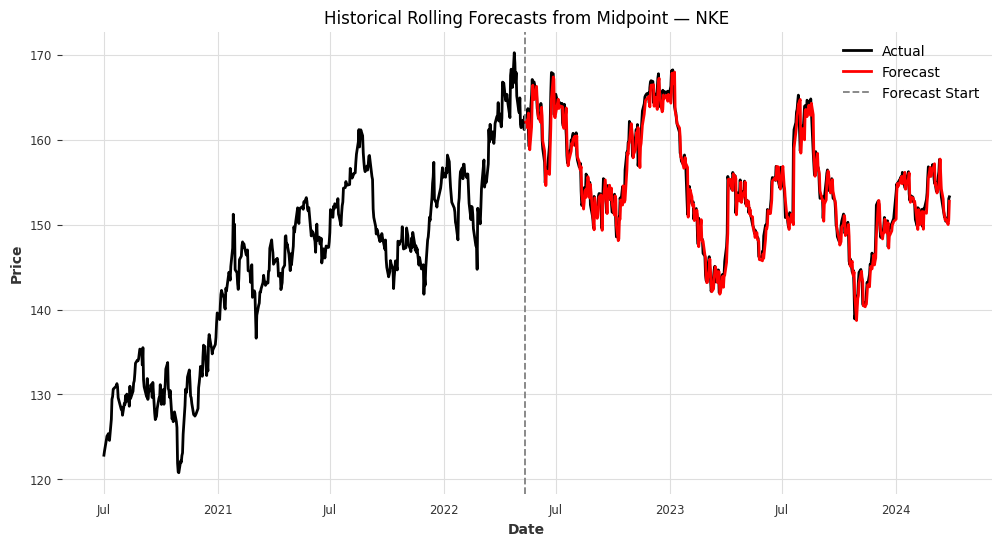

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for NKE: MAPE=0.75%, SMAPE=0.75%, MAE=1.1610, MSE=2.49, R²=0.941
Directional Accuracy for NKE: 56.17%



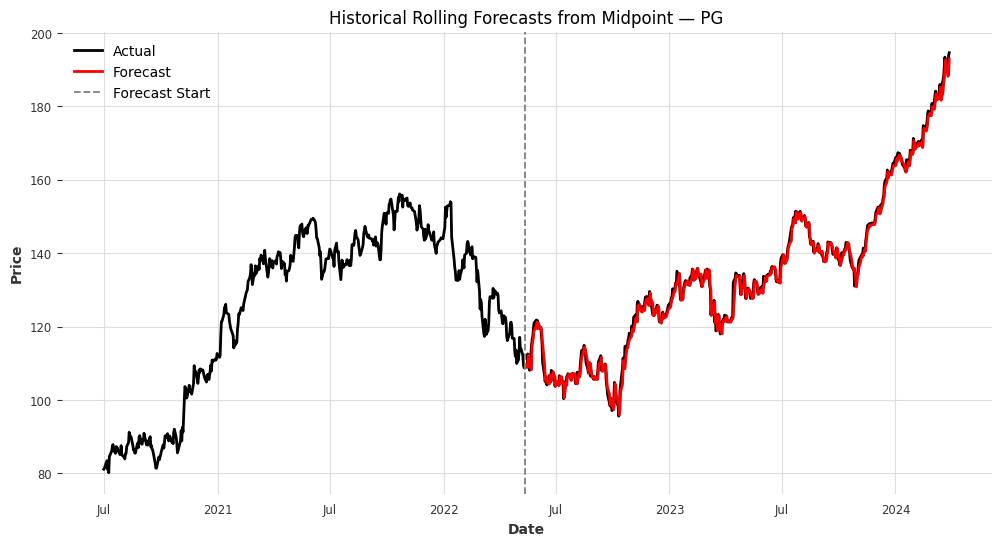

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for PG: MAPE=1.11%, SMAPE=1.11%, MAE=1.4353, MSE=3.51, R²=0.993
Directional Accuracy for PG: 48.72%



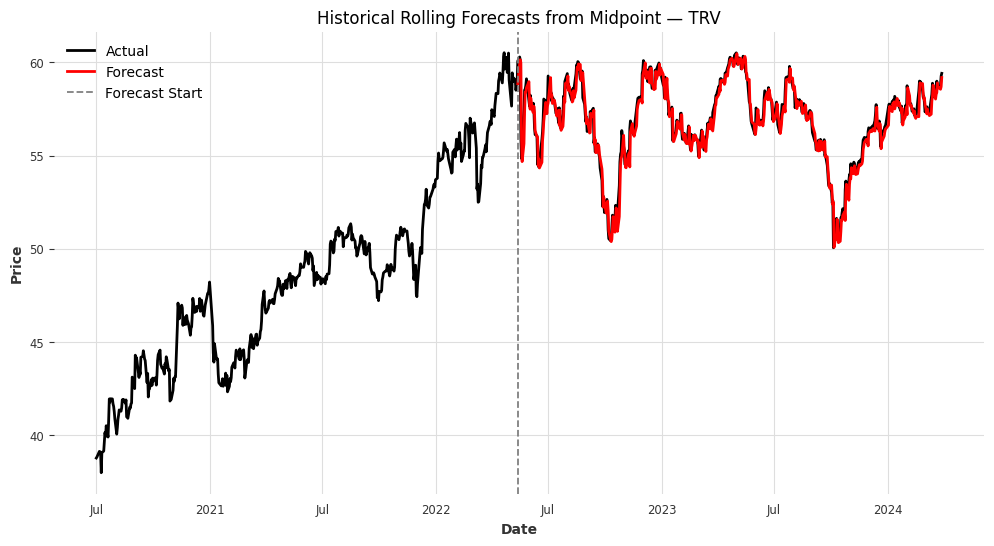

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for TRV: MAPE=0.75%, SMAPE=0.75%, MAE=0.4210, MSE=0.33, R²=0.929
Directional Accuracy for TRV: 48.72%



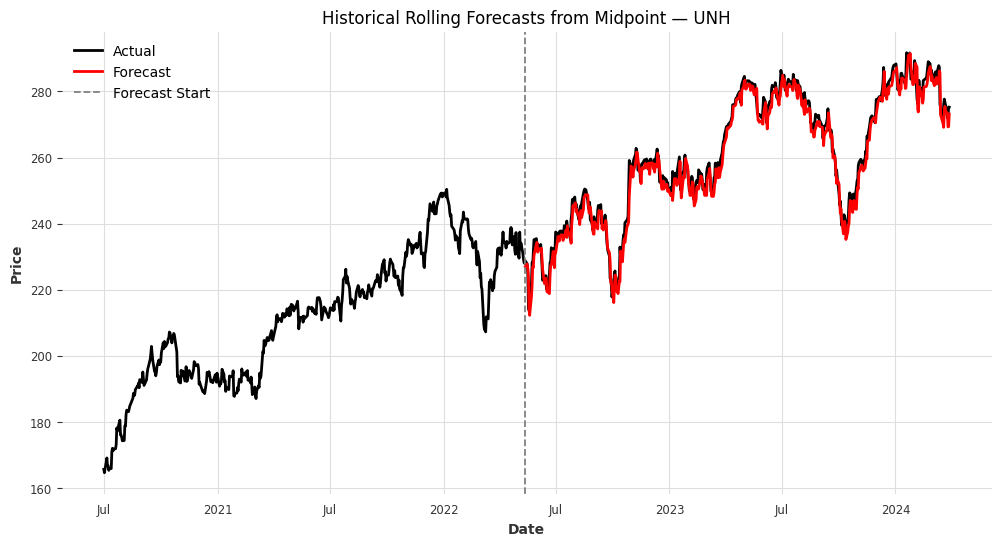

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for UNH: MAPE=0.94%, SMAPE=0.95%, MAE=2.4382, MSE=9.68, R²=0.973
Directional Accuracy for UNH: 52.77%



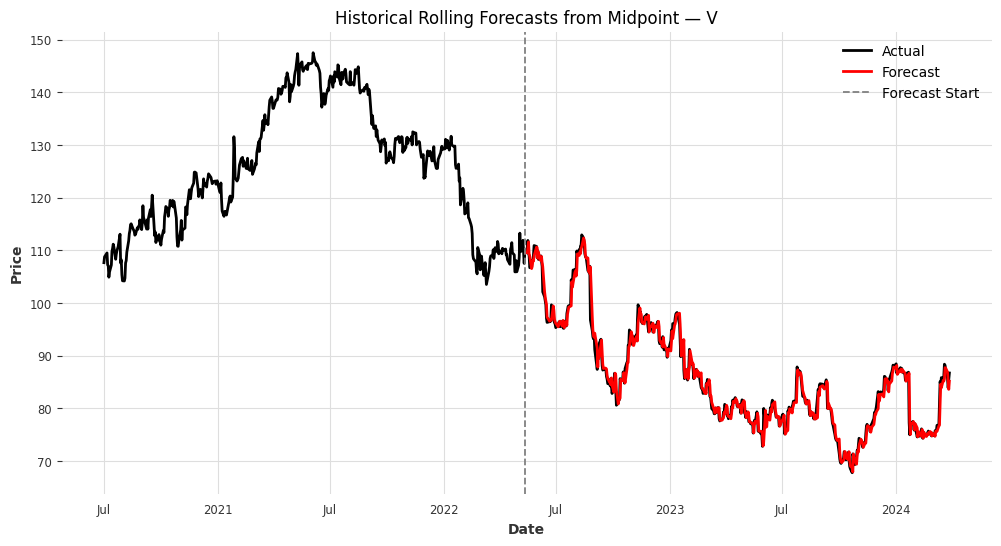

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for V: MAPE=1.26%, SMAPE=1.26%, MAE=1.0830, MSE=2.46, R²=0.977
Directional Accuracy for V: 49.15%



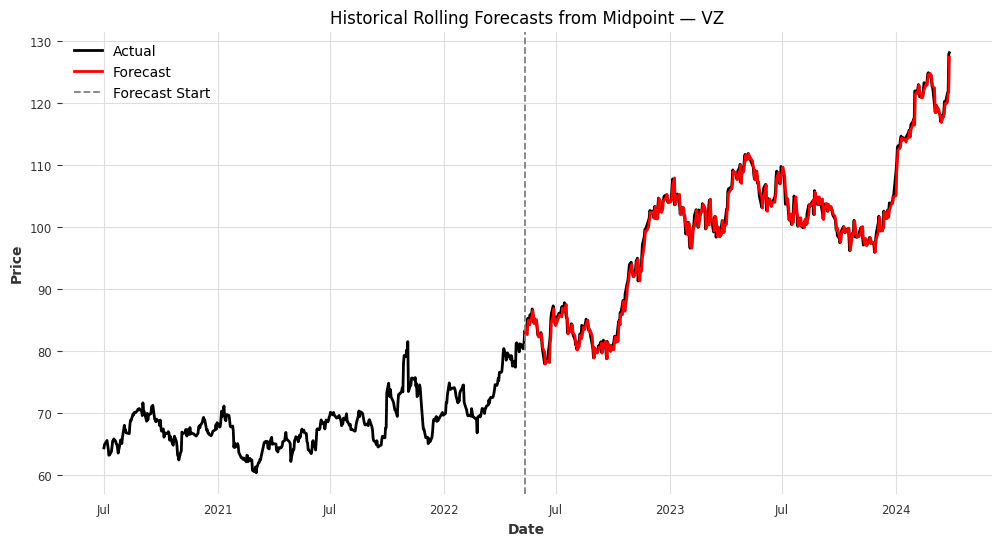

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for VZ: MAPE=0.93%, SMAPE=0.93%, MAE=0.9186, MSE=1.51, R²=0.989
Directional Accuracy for VZ: 51.70%



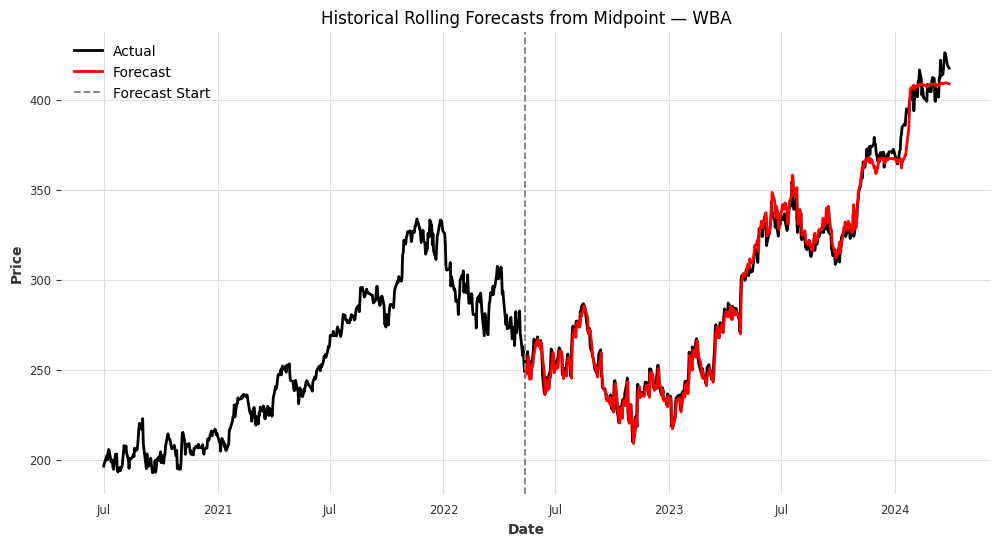

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for WBA: MAPE=1.60%, SMAPE=1.61%, MAE=4.8023, MSE=40.54, R²=0.988
Directional Accuracy for WBA: 53.62%



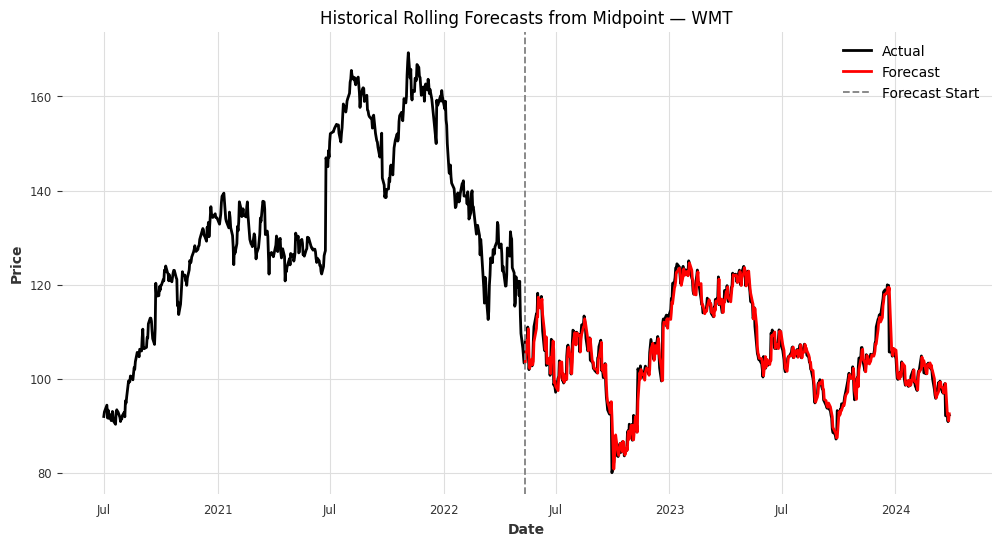

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for WMT: MAPE=1.51%, SMAPE=1.51%, MAE=1.5735, MSE=4.91, R²=0.947
Directional Accuracy for WMT: 49.36%



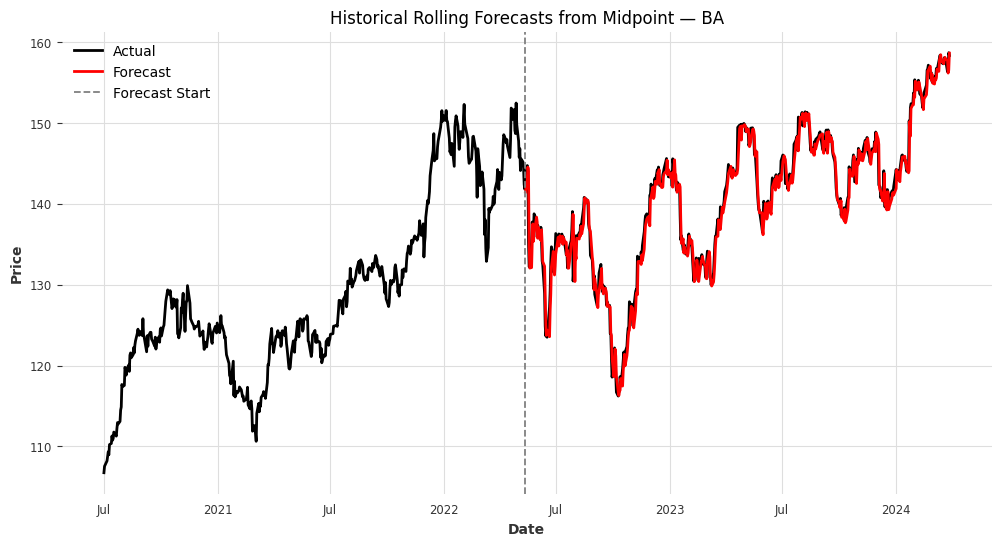

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for BA: MAPE=0.81%, SMAPE=0.81%, MAE=1.1279, MSE=2.39, R²=0.969
Directional Accuracy for BA: 50.64%



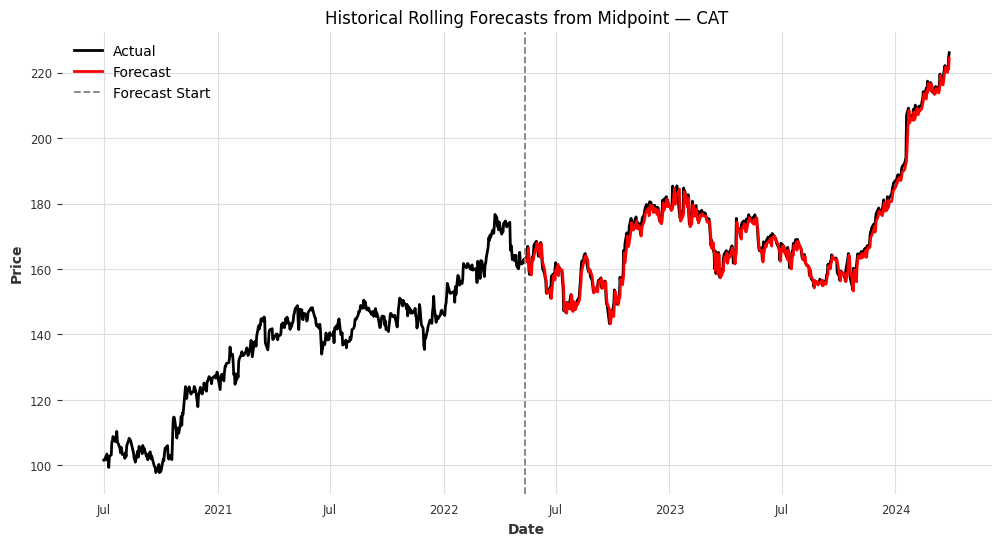

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CAT: MAPE=1.07%, SMAPE=1.07%, MAE=1.8209, MSE=5.58, R²=0.982
Directional Accuracy for CAT: 50.64%



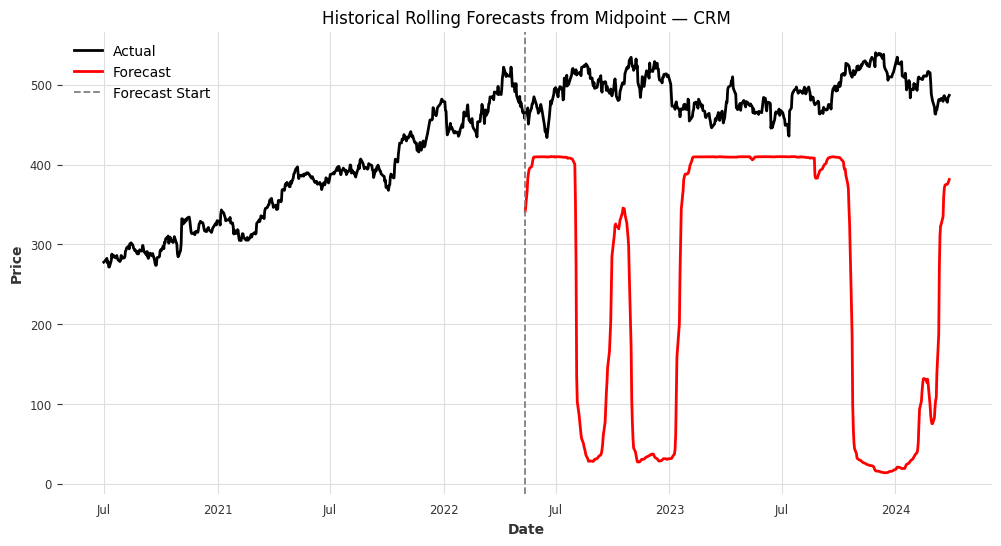

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CRM: MAPE=46.55%, SMAPE=78.07%, MAE=235.2701, MSE=91137.24, R²=-161.669
Directional Accuracy for CRM: 51.28%



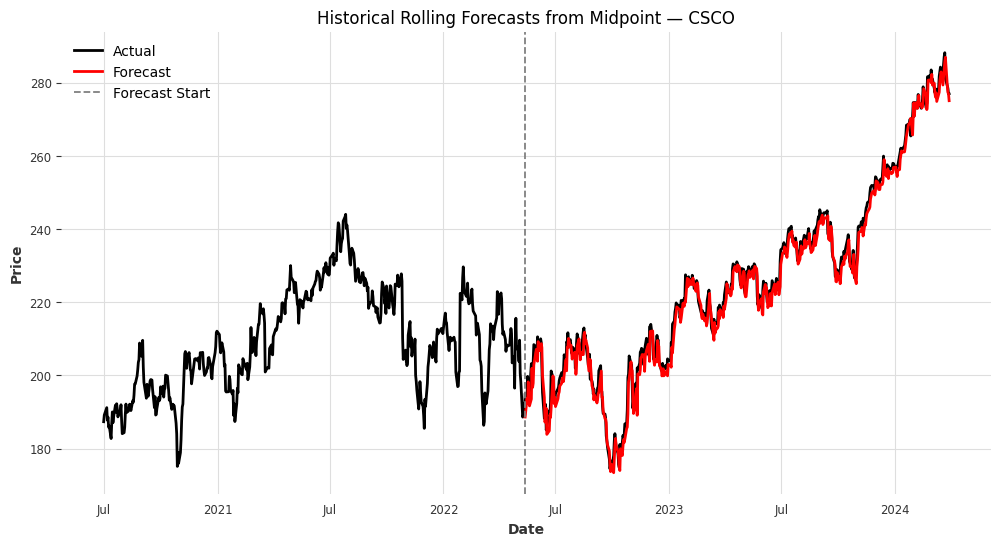

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CSCO: MAPE=1.08%, SMAPE=1.09%, MAE=2.3841, MSE=9.18, R²=0.987
Directional Accuracy for CSCO: 49.15%



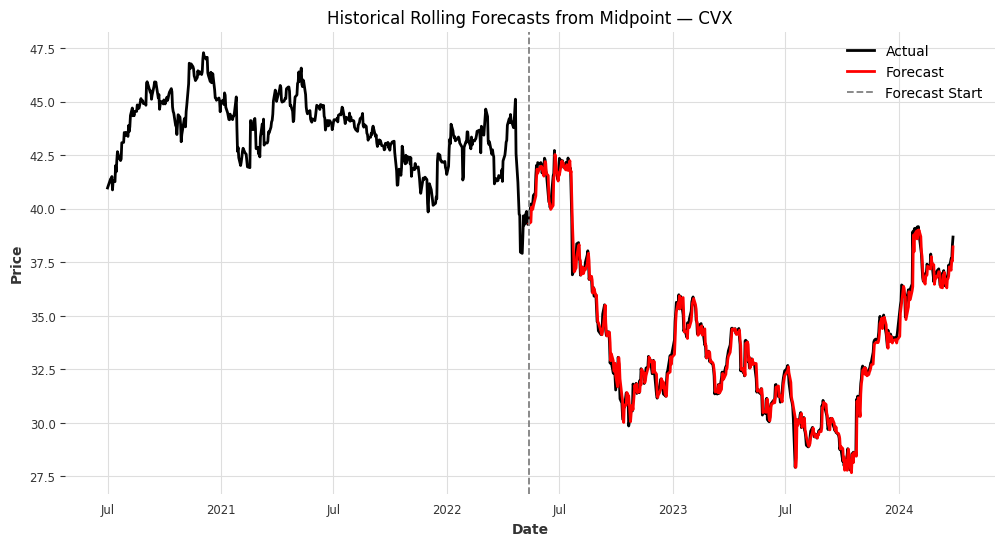

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Metrics for CVX: MAPE=1.04%, SMAPE=1.04%, MAE=0.3517, MSE=0.24, R²=0.981
Directional Accuracy for CVX: 48.72%



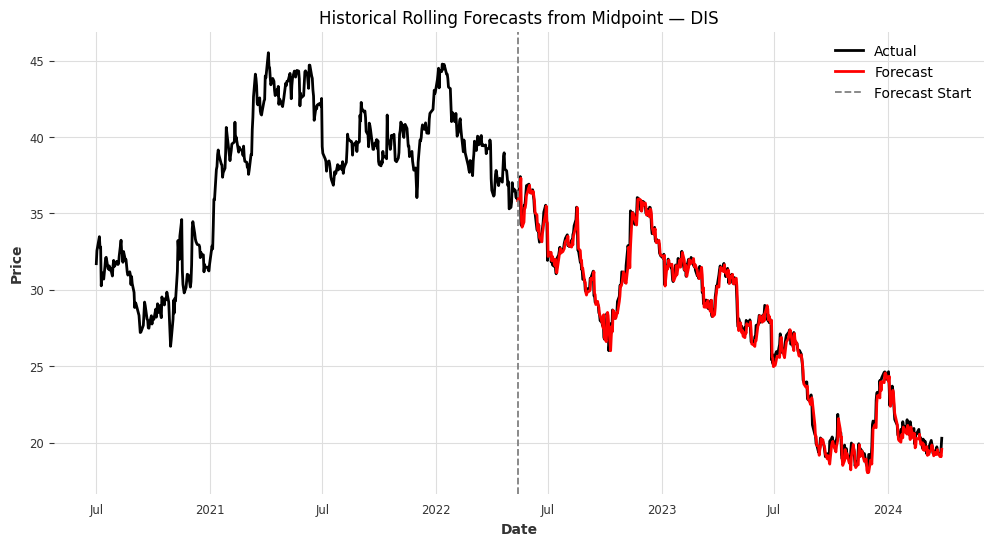

Metrics for DIS: MAPE=1.63%, SMAPE=1.63%, MAE=0.4325, MSE=0.35, R²=0.988
Directional Accuracy for DIS: 47.87%

=== Average metrics across all stocks ===
Avg MAE:   1.9932
Avg MSE:   10.34
Avg MAPE:  1.27%
Avg SMAPE: 1.28%
Avg R²:    0.971
Avg Dir Acc: 51.50%


In [8]:
from darts.metrics import mape, smape, mae, mse, r2_score


# reindex for DJIA30 tickers
# can remove this part for other collection of stocks
real_tickers = ["AMZN", "AMGN","GS","HD","HON","IBM","INTC","JNJ","JPM","KO","MCD","MMM",
                "AXP","MRK","MSFT","NKE","PG","TRV","UNH","V","VZ","WBA","WMT",
                "BA","CAT","CRM","CSCO","CVX","DIS","DOW"]


# this is to account to the tickers that are added/kicked out of DJIA30 over time
exclude = {"CRM"}



# init accumulators
mape_list   = []
smape_list  = []
mae_list    = []
mse_list    = []
r2_list     = []
dir_acc_list = []


def add_symbol_static(ts, sym):
    return ts.with_static_covariates(pd.DataFrame({"symbol": [sym]}))

train_target_list = [
    add_symbol_static(ts, sym)
    for ts, sym in zip(train_target_list, real_tickers)
]
val_target_list = [
    add_symbol_static(ts, sym)
    for ts, sym in zip(val_target_list, real_tickers)
]




# fit scalers on train targets
scaler_dict = {i: Scaler().fit(ts) for i, ts in enumerate(train_target_list)}

symbols = np.array(real_tickers)

for idx, ts_val in enumerate(val_target_list):
    # grab the real symbol name
    symbol = ts_val.static_covariates['symbol'][0]

    # determine start date at midpoint
    mid_idx    = len(ts_val) // 2
    start_date = ts_val.time_index[mid_idx]

    # generate one-step historical forecasts from midpoint to end
    fc_hist = model.historical_forecasts(
        series=ts_val,
        past_covariates=val_past_cov_list[idx],
        start=start_date,
        forecast_horizon=1,
        stride=1,
        retrain=False,
        verbose=False
    )

    # inverse scale
    actual_u = ts_val
    forecast_u = fc_hist

    # plot actual and forecast
    plt.figure(figsize=(12,6))
    actual_u.plot(label='Actual', color='black')
    forecast_u.plot(label='Forecast', color='red')
    plt.axvline(start_date, color='grey', linestyle='--', label='Forecast Start')
    plt.title(f'Historical Rolling Forecasts from Midpoint — {symbols[idx]}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

    # metrics over forecast period
    common     = forecast_u.time_index.intersection(actual_u.time_index)
    actual_sub = actual_u.slice(common[0], common[-1])
    pred_sub   = forecast_u

    mape_val   = mape(actual_sub, pred_sub)
    smape_val  = smape(actual_sub, pred_sub)
    mae_val    = mae(actual_sub, pred_sub)
    mse_val    = mse(actual_sub, pred_sub)
    r2_val     = r2_score(actual_sub, pred_sub)
    print(
        f"Metrics for {symbol}: "
        f"MAPE={mape_val:.2f}%, SMAPE={smape_val:.2f}%, MAE={mae_val:.4f}, MSE={mse_val:.2f}, R²={r2_val:.3f}"
    )

    # directional accuracy
    import pandas as _pd
    actual_series   = _pd.Series(actual_u.values().flatten(),   index=actual_u.time_index)
    forecast_series = _pd.Series(forecast_u.values().flatten(), index=forecast_u.time_index)
    common_idx2     = actual_series.index.intersection(forecast_series.index)
    actual_aligned  = actual_series.loc[common_idx2].diff().dropna()
    pred_aligned    = forecast_series.loc[common_idx2].diff().dropna()
    dir_acc         = (actual_aligned * pred_aligned > 0).sum() / len(actual_aligned) * 100
    print(f"Directional Accuracy for {symbol}: {dir_acc:.2f}%\n")

    # append to accumulators
    if symbols[idx] not in exclude:
        mape_list.append(mape_val)
        smape_list.append(smape_val)
        mae_list.append(mae_val)
        mse_list.append(mse_val)
        r2_list.append(r2_val)
        dir_acc_list.append(dir_acc)



# after loop: overall averages
print("=== Average metrics across all stocks ===")
print(f"Avg MAE:   {np.mean(mae_list):.4f}")
print(f"Avg MSE:   {np.mean(mse_list):.2f}")
print(f"Avg MAPE:  {np.mean(mape_list):.2f}%")
print(f"Avg SMAPE: {np.mean(smape_list):.2f}%")
print(f"Avg R²:    {np.mean(r2_list):.3f}")
print(f"Avg Dir Acc: {np.mean(dir_acc_list):.2f}%")

In [9]:
# save predictions to csv file for RL agent

rows = []

for idx, ts_val in enumerate(val_target_list):
    symbol = ts_val.static_covariates["symbol"][0]
    mid_idx    = len(ts_val) // 2
    start_date = ts_val.time_index[mid_idx]

    fc_hist = model.historical_forecasts(
        series=ts_val,
        past_covariates=val_past_cov_list[idx],
        start=start_date,
        forecast_horizon=1,
        stride=1,
        retrain=False,
        verbose=False
    )

    common     = fc_hist.time_index.intersection(ts_val.time_index)
    actual_sub = ts_val.slice(common[0], common[-1])
    pred_sub   = fc_hist  # already aligned one-by-one

    df_tmp = pd.DataFrame({
        "date":    pred_sub.time_index,    # pandas-like index
        "ticker":  symbol,
        "actual":  actual_sub.values().flatten(),
        "forecast":pred_sub.values().flatten()
    })
    rows.append(df_tmp)


rolling_df = pd.concat(rows, ignore_index=True)
rolling_df.to_csv("rolling_one_step_forecasts.csv", index=False)
print("✓ Saved rolling forecasts to rolling_one_step_forecasts.csv")


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lig

✓ Saved rolling forecasts to rolling_one_step_forecasts.csv


## Finetuning


In [11]:
# note that here we are using the "test_data" file as our finetune dataset and
# testing on our validation dataset (so that we align the metrics timeframe with the model freshly after training)
# in the future, maybe finetune on bigger datasets

model.fit(
    series=test_target_list,
    past_covariates=test_past_cov_list,

    # validate on your original validation split
    val_series=val_target_list,
    val_past_covariates=val_past_cov_list,

    # run 10 more epochs
    epochs=10,


    verbose=True
)


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
   | Name                              | Type                             | Params | Mode 
------------------------------------------------------------------------------------------------
0  | criterion                         | SmoothL1Loss                     | 0      | train
1  | train_criterion                   | SmoothL1Loss                     | 0      | train
2  | val_criterion                     | SmoothL1Loss                     | 0      | train
3  | train_metrics                     | MetricCollection                 | 0      | train
4  | val_metrics                       | MetricCollection               

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


TFTModel(output_chunk_shift=0, hidden_size=64, lstm_layers=2, num_attention_heads=4, full_attention=False, feed_forward=GatedResidualNetwork, dropout=0.2, hidden_continuous_size=8, categorical_embedding_sizes=None, add_relative_index=True, loss_fn=SmoothL1Loss(), likelihood=None, norm_type=LayerNorm, use_static_covariates=False, input_chunk_length=30, output_chunk_length=1, batch_size=32, n_epochs=100, add_encoders=None, random_state=42, force_reset=True, pl_trainer_kwargs={'accelerator': 'gpu', 'gradient_clip_val': 0.1, 'enable_progress_bar': True, 'max_epochs': 100, 'check_val_every_n_epoch': 1, 'log_every_n_steps': 10, 'logger': True, 'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x7f8f503c3950>]})

In [20]:
# visualize and print metrics again after finetuning


from darts.metrics import mape, smape, mae, mse, r2_score


# reindex for DJIA30 tickers
# can remove this part for other collection of stocks
real_tickers = ["AMZN", "AMGN","GS","HD","HON","IBM","INTC","JNJ","JPM","KO","MCD","MMM",
                "AXP","MRK","MSFT","NKE","PG","TRV","UNH","V","VZ","WBA","WMT",
                "BA","CAT","CRM","CSCO","CVX","DIS","DOW"]


# this is to account to the tickers that are added/kicked out of DJIA30 over time
exclude = {"CRM"}



# init accumulators
mape_list   = []
smape_list  = []
mae_list    = []
mse_list    = []
r2_list     = []
dir_acc_list = []


def add_symbol_static(ts, sym):
    return ts.with_static_covariates(pd.DataFrame({"symbol": [sym]}))

train_target_list = [
    add_symbol_static(ts, sym)
    for ts, sym in zip(train_target_list, real_tickers)
]
val_target_list = [
    add_symbol_static(ts, sym)
    for ts, sym in zip(val_target_list, real_tickers)
]




# fit scalers on train targets
scaler_dict = {i: Scaler().fit(ts) for i, ts in enumerate(train_target_list)}

symbols = np.array(real_tickers)

for idx, ts_val in enumerate(val_target_list):
    # grab the real symbol name
    symbol = ts_val.static_covariates['symbol'][0]

    # determine start date at midpoint
    mid_idx    = len(ts_val) // 2
    start_date = ts_val.time_index[mid_idx]

    # generate one-step historical forecasts from midpoint to end
    fc_hist = model.historical_forecasts(
        series=ts_val,
        past_covariates=val_past_cov_list[idx],
        start=start_date,
        forecast_horizon=1,
        stride=1,
        retrain=False,
        verbose=False
    )

    # inverse scale
    actual_u = ts_val
    forecast_u = fc_hist

    # plot actual and forecast
    plt.figure(figsize=(12,6))
    actual_u.plot(label='Actual', color='black')
    forecast_u.plot(label='Forecast', color='red')
    plt.axvline(start_date, color='grey', linestyle='--', label='Forecast Start')
    plt.title(f'Historical Rolling Forecasts from Midpoint — {symbols[idx]}')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

    # metrics over forecast period
    common     = forecast_u.time_index.intersection(actual_u.time_index)
    actual_sub = actual_u.slice(common[0], common[-1])
    pred_sub   = forecast_u

    mape_val   = mape(actual_sub, pred_sub)
    smape_val  = smape(actual_sub, pred_sub)
    mae_val    = mae(actual_sub, pred_sub)
    mse_val    = mse(actual_sub, pred_sub)
    r2_val     = r2_score(actual_sub, pred_sub)
    print(
        f"Metrics for {symbol}: "
        f"MAPE={mape_val:.2f}%, SMAPE={smape_val:.2f}%, MAE={mae_val:.4f}, MSE={mse_val:.2f}, R²={r2_val:.3f}"
    )

    # directional accuracy
    import pandas as _pd
    actual_series   = _pd.Series(actual_u.values().flatten(),   index=actual_u.time_index)
    forecast_series = _pd.Series(forecast_u.values().flatten(), index=forecast_u.time_index)
    common_idx2     = actual_series.index.intersection(forecast_series.index)
    actual_aligned  = actual_series.loc[common_idx2].diff().dropna()
    pred_aligned    = forecast_series.loc[common_idx2].diff().dropna()
    dir_acc         = (actual_aligned * pred_aligned > 0).sum() / len(actual_aligned) * 100
    print(f"Directional Accuracy for {symbol}: {dir_acc:.2f}%\n")

    # append to accumulators
    if symbols[idx] not in exclude:
        mape_list.append(mape_val)
        smape_list.append(smape_val)
        mae_list.append(mae_val)
        mse_list.append(mse_val)
        r2_list.append(r2_val)
        dir_acc_list.append(dir_acc)



# after loop: overall averages
print("=== Average metrics across all stocks ===")
print(f"Avg MAE:   {np.mean(mae_list):.4f}")
print(f"Avg MSE:   {np.mean(mse_list):.2f}")
print(f"Avg MAPE:  {np.mean(mape_list):.2f}%")
print(f"Avg SMAPE: {np.mean(smape_list):.2f}%")
print(f"Avg R²:    {np.mean(r2_list):.3f}")
print(f"Avg Dir Acc: {np.mean(dir_acc_list):.2f}%")

AttributeError: 'MultiplexTransformerForecaster' object has no attribute 'historical_forecasts'

# (Optional) Vanilla Transformer Model
This is another model that we implemented, but does not perform as well compared to the TFT Transformer model

## Multiplex Attention Block

In [13]:

class MultiplexAttention(nn.Module):
    """Applies self‑attention independently to three modality streams and concatenates the results"""

    def __init__(self, dim: int, num_heads: int):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.attn_stock = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.attn_sent  = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        self.attn_macro = nn.MultiheadAttention(dim, num_heads, batch_first=True)
        # projection after concat of 3*dim back to dim
        self.out_proj   = nn.Linear(3*dim, dim)
        #self.norm = nn.LayerNorm(dim)



    def forward(self, x_stock, x_sent, x_macro, key_padding_mask=None):
        seq_len = x_stock.size(1)
        attn_mask = torch.triu(torch.ones(seq_len, seq_len) * float('-inf'), diagonal=1).to(x_stock.device)

        # each input: [B, T, D]
        a_stock, _ = self.attn_stock(x_stock, x_stock, x_stock,
                                     key_padding_mask=key_padding_mask,
                                     attn_mask=attn_mask)
        a_sent,  _ = self.attn_sent(x_sent, x_sent, x_sent,
                                    key_padding_mask=key_padding_mask,
                                    attn_mask=attn_mask)
        a_macro, _ = self.attn_macro(x_macro, x_macro, x_macro,
                                     key_padding_mask=key_padding_mask,
                                     attn_mask=attn_mask)
        # concat on last dim
        cat = torch.cat([a_stock, a_sent, a_macro], dim=-1)
        out = self.out_proj(cat)
        #return self.norm(out)
        return out


## Transformer Forecasting Model

In [14]:

class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer('pe', pe)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return x

class MultiplexTransformerForecaster(nn.Module):
    def __init__(self,
                 dim: int = 64,
                 num_heads: int = 4,
                 num_layers: int = 2,
                 horizon: int = HORIZON_SIZE,
                 dropout: float = 0.2,
                 tech_dim:  int = TECH_DIM,
                 sent_dim:  int = SENT_DIM,
                 macro_dim: int = MACRO_DIM,
                 window:    int = WINDOW_SIZE):
        super().__init__()
        self.horizon = horizon
        self.window  = window
        self.attn_norm = nn.LayerNorm(dim)

        # modality‑specific projections
        self.embed_stock = nn.Linear(tech_dim,  dim)
        self.embed_sent  = nn.Linear(sent_dim,  dim)
        self.embed_macro = nn.Linear(macro_dim, dim)

        self.pos_enc = PositionalEncoding(dim)

        blocks = []
        for _ in range(num_layers):
            blocks.append(MultiplexAttention(dim, num_heads))
            blocks.append(nn.Sequential(
                nn.LayerNorm(dim),
                nn.Linear(dim, dim*4), nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(dim*4, dim)
            ))
        self.layers = nn.ModuleList(blocks)

        # prediction head: produce horizon × 4 prices, not just horizon
        self.pred_head = nn.Sequential(
            nn.LayerNorm(dim),
            nn.Flatten(start_dim=1),                      # [B, window*dim]
            nn.Linear(dim * window, horizon * 4)
        )



    def forward(self, x_stock, x_sent, x_macro):          # [B, T, F*]
        s = self.embed_stock(x_stock)
        t = self.embed_sent(x_sent)
        m = self.embed_macro(x_macro)

        s, t, m = map(self.pos_enc, (s, t, m))

        for blk in self.layers:
            if isinstance(blk, MultiplexAttention):
                residual = s
                s = t = m = blk(s, t, m)
                s = s + residual
                s = self.attn_norm(s)
            else:                         # feed‑forward
                s = s + blk(s)
                t = m = s

        # price prediction
        price_logits = self.pred_head(s)        # [B, horizon*4]
        price_pred   = price_logits.view(-1, self.horizon, 4)

        return price_pred


## Training Loop


In [19]:
# Setup

train_ds = MultiCSVWindowDataset('aligned_data_train.npz', WINDOW_SIZE, HORIZON_SIZE)
val_ds   = MultiCSVWindowDataset('aligned_data_val.npz',   WINDOW_SIZE, HORIZON_SIZE)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiplexTransformerForecaster(
    tech_dim  = train_ds.stock.shape[-1],
    sent_dim  = train_ds.sent.shape[-1],
    macro_dim = train_ds.macro.shape[-1],
    window    = WINDOW_SIZE,
    horizon   = HORIZON_SIZE
).to(device)

optimizer  = torch.optim.AdamW(model.parameters(),
                               lr=LEARNING_RATE,
                               weight_decay=WEIGHT_DECAY)

scheduler  = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = LEARNING_RATE,
    total_steps = NUM_EPOCHS * len(train_loader),
    pct_start   = 0.1,
    anneal_strategy = "cos"
)

mse_loss  = nn.SmoothL1Loss()
GRAD_CLIP = 1.0


# Training / evaluation loops (pure-MSE)
def train_epoch():
    model.train()
    total_loss = total_correct = total_samples = 0

    for x_s, x_t, x_m, y, prev_close, _ in train_loader:
        x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
        y          = y.to(device).squeeze(-1)          # (B, H)
        prev_close = prev_close.to(device)

        optimizer.zero_grad()
        y_hat = model(x_s, x_t, x_m)[..., 3]           # CLOSE channel
        loss  = mse_loss(y_hat, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        B = y.size(0)
        total_samples += B
        total_loss    += loss.item() * B
        total_correct += ((y_hat[:, 0] > prev_close) ==
                          (y[:,    0] > prev_close)).sum().item()

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate_epoch():
    model.eval()
    total_loss = total_correct = total_samples = 0

    for x_s, x_t, x_m, y, prev_close, _ in val_loader:
        x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
        y          = y.to(device).squeeze(-1)
        prev_close = prev_close.to(device)

        y_hat = model(x_s, x_t, x_m)[..., 3]           # CLOSE channel
        loss  = mse_loss(y_hat, y)

        B = y.size(0)
        total_samples += B
        total_loss    += loss.item() * B
        total_correct += ((y_hat[:, 0] > prev_close) ==
                          (y[:,    0] > prev_close)).sum().item()

    return total_loss / total_samples, total_correct / total_samples



# Training driver
all_up = []
for _, _, _, y, prev, _ in val_loader:
    all_up.append((y.squeeze(-1)[:, 0] > prev).long())
all_up = torch.cat(all_up)
print("Up fraction in val set:", all_up.float().mean().item())

for epoch in range(50): # or change to N_EPOCHS here
    train_loss, train_acc = train_epoch()
    val_loss,   val_acc   = evaluate_epoch()
    print(f"Epoch {epoch+1:02d} │ "
          f"train loss={train_loss:.4f} acc={train_acc:.4f} │ "
          f"val loss={val_loss:.4f} acc={val_acc:.4f}")


Up fraction in val set: 0.515141487121582
Epoch 01 │ train loss=24.1111 acc=0.4919 │ val loss=67.4630 acc=0.4878
Epoch 02 │ train loss=6.0030 acc=0.5037 │ val loss=34.3241 acc=0.4940
Epoch 03 │ train loss=3.4429 acc=0.5059 │ val loss=19.2176 acc=0.4955
Epoch 04 │ train loss=2.7268 acc=0.5039 │ val loss=10.4797 acc=0.5099
Epoch 05 │ train loss=2.5317 acc=0.5043 │ val loss=8.8447 acc=0.4915
Epoch 06 │ train loss=2.1577 acc=0.5038 │ val loss=8.7927 acc=0.5133
Epoch 07 │ train loss=2.0368 acc=0.5056 │ val loss=6.9927 acc=0.5054
Epoch 08 │ train loss=1.8456 acc=0.5037 │ val loss=7.9357 acc=0.4944
Epoch 09 │ train loss=1.7152 acc=0.5047 │ val loss=7.5197 acc=0.5162
Epoch 10 │ train loss=1.6507 acc=0.5040 │ val loss=7.1709 acc=0.4919
Epoch 11 │ train loss=1.5860 acc=0.5052 │ val loss=8.5234 acc=0.5106
Epoch 12 │ train loss=1.5111 acc=0.5046 │ val loss=6.4489 acc=0.5109
Epoch 13 │ train loss=1.4338 acc=0.5053 │ val loss=6.8735 acc=0.4916
Epoch 14 │ train loss=1.3973 acc=0.5061 │ val loss=6.612

## Prediction & Visualization

In [21]:
# predict function
@torch.no_grad()
def predict(loader):
    model.eval()
    preds, truths = [], []

    for x_s, x_t, x_m, y, _, _ in loader:
        x_s, x_t, x_m = [t.to(device) for t in (x_s, x_t, x_m)]
        y_hat = model(x_s, x_t, x_m)[..., 3]  # CLOSE channel
        preds.append(y_hat.cpu())
        truths.append(y.squeeze(-1))

    return torch.cat(preds, dim=0), torch.cat(truths, dim=0)


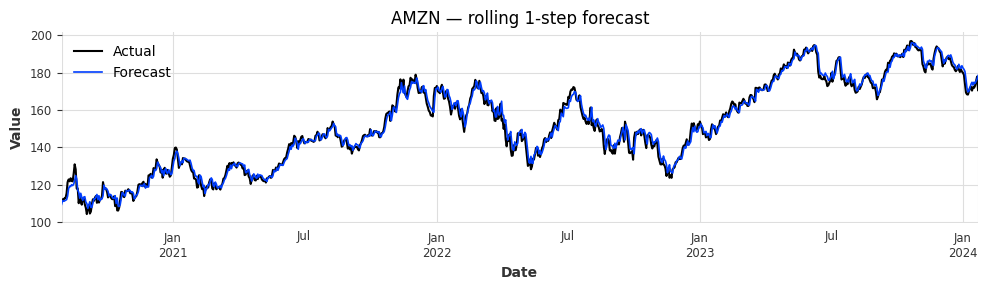

AMZN: MAPE=1.49%, MSE=8.5272, MAE=2.1956, R²=0.984, DirAcc=50.66%



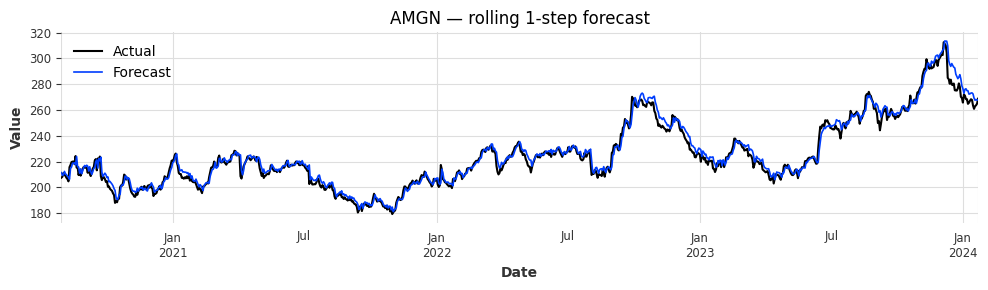

AMGN: MAPE=1.37%, MSE=17.9830, MAE=3.1063, R²=0.973, DirAcc=50.66%



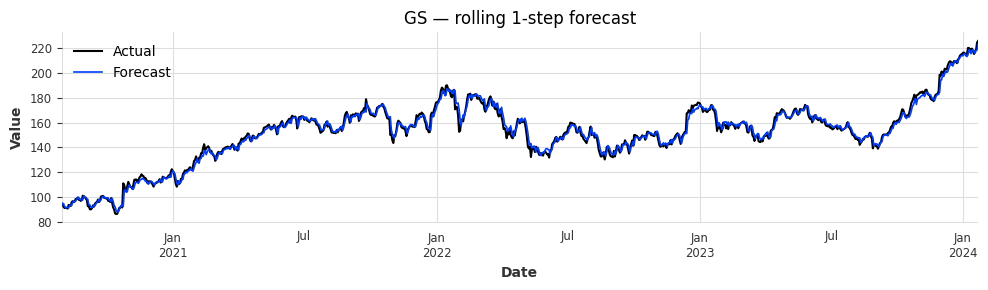

GS: MAPE=1.59%, MSE=10.4507, MAE=2.3795, R²=0.984, DirAcc=51.10%



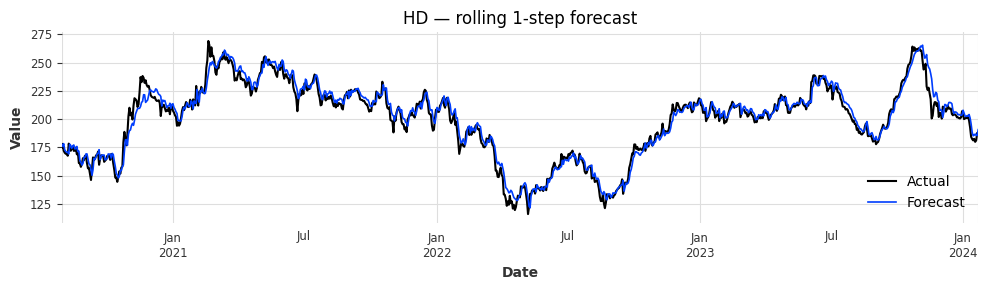

HD: MAPE=2.47%, MSE=42.6677, MAE=4.8170, R²=0.958, DirAcc=51.10%



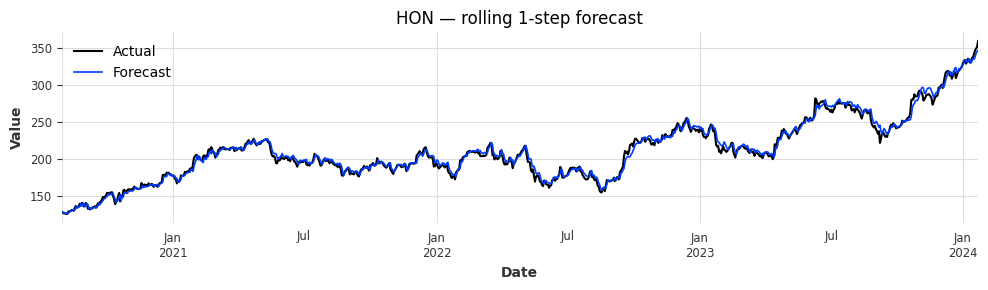

HON: MAPE=1.75%, MSE=24.4597, MAE=3.6697, R²=0.986, DirAcc=53.42%



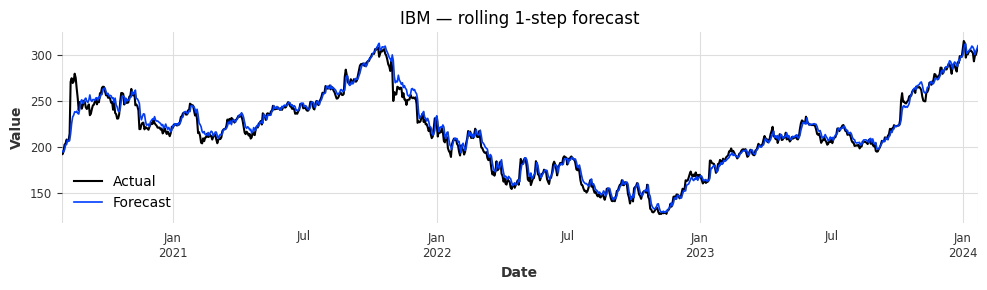

IBM: MAPE=2.22%, MSE=49.2760, MAE=4.6944, R²=0.972, DirAcc=50.77%



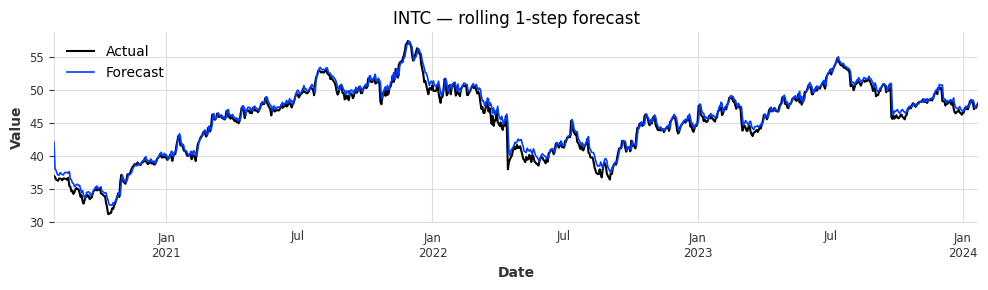

INTC: MAPE=1.39%, MSE=0.7160, MAE=0.6123, R²=0.975, DirAcc=50.66%



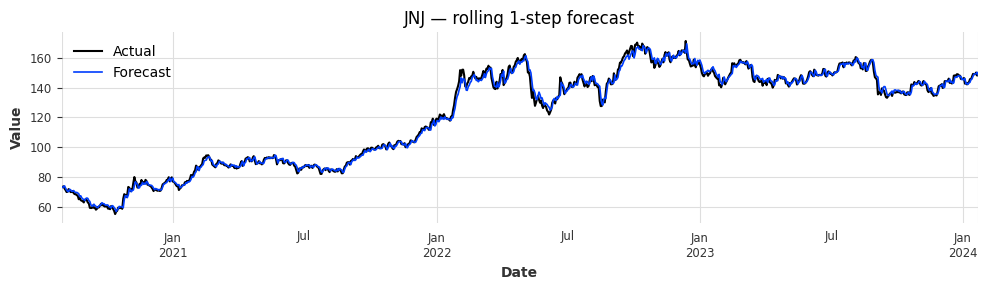

JNJ: MAPE=1.50%, MSE=5.9822, MAE=1.7766, R²=0.994, DirAcc=50.11%



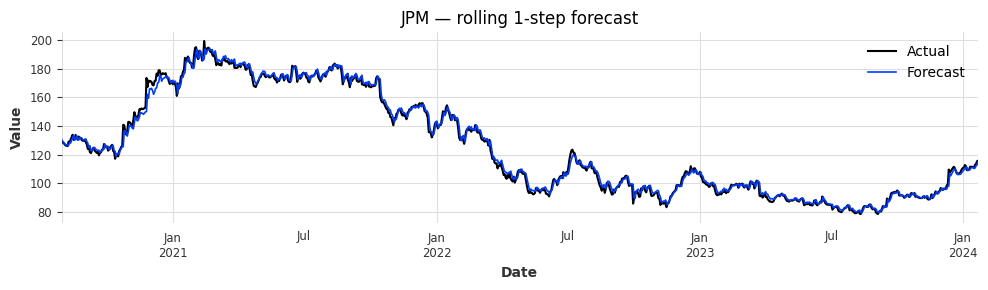

JPM: MAPE=1.64%, MSE=8.2175, MAE=2.0282, R²=0.994, DirAcc=50.00%



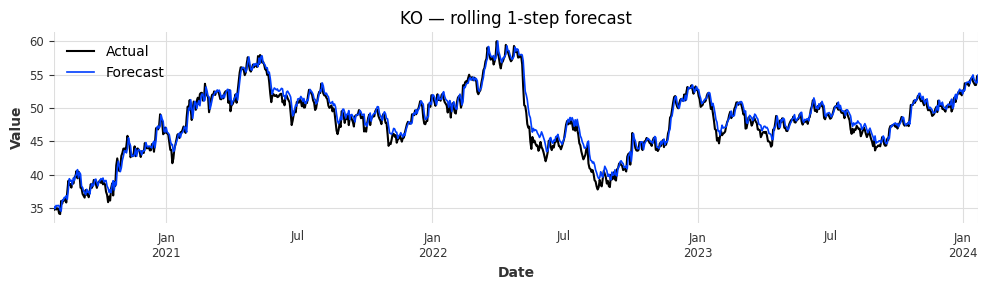

KO: MAPE=1.65%, MSE=1.0203, MAE=0.7702, R²=0.958, DirAcc=50.66%



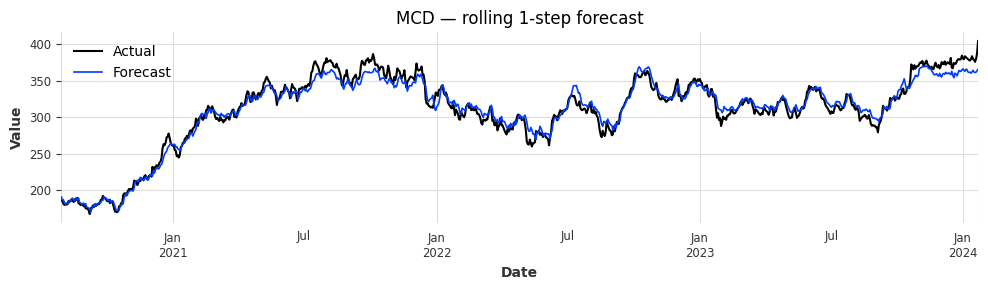

MCD: MAPE=2.28%, MSE=84.5192, MAE=7.2117, R²=0.967, DirAcc=51.55%



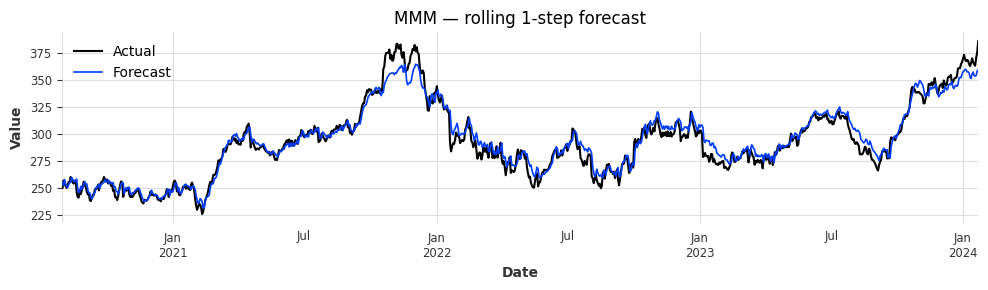

MMM: MAPE=1.85%, MSE=55.1644, MAE=5.5030, R²=0.952, DirAcc=50.77%



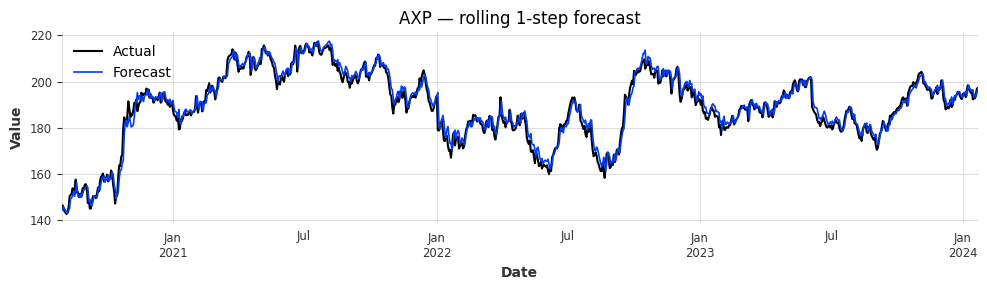

AXP: MAPE=1.21%, MSE=8.7054, MAE=2.2425, R²=0.963, DirAcc=50.11%



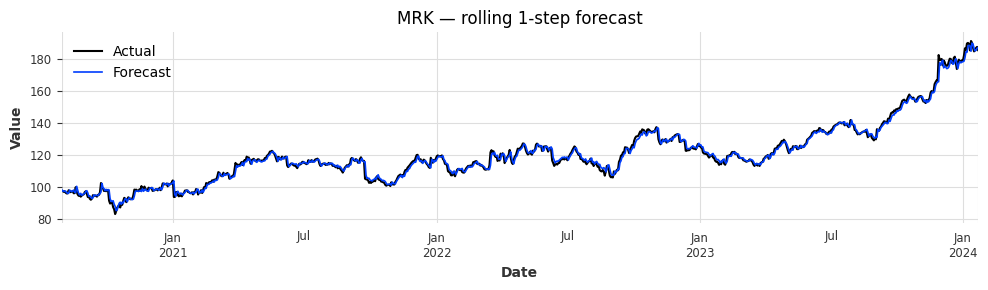

MRK: MAPE=1.11%, MSE=3.4642, MAE=1.3277, R²=0.991, DirAcc=50.33%



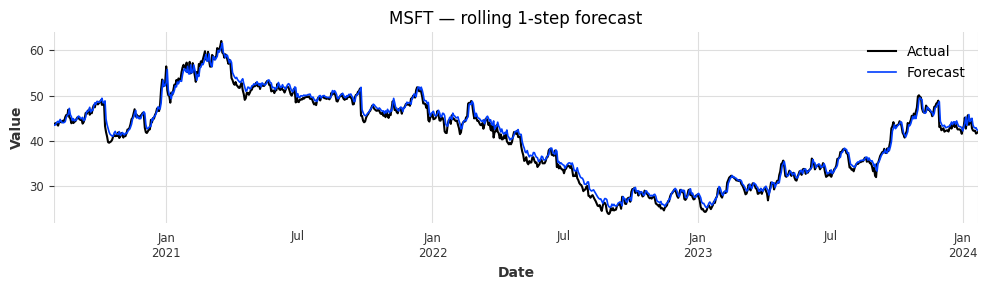

MSFT: MAPE=2.19%, MSE=1.2803, MAE=0.8496, R²=0.985, DirAcc=51.43%



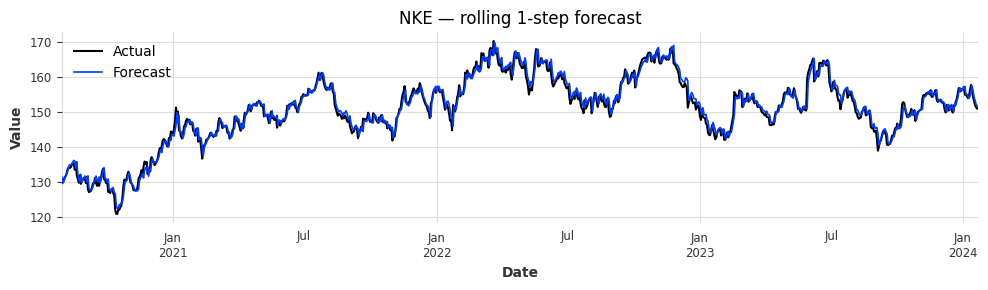

NKE: MAPE=0.82%, MSE=2.6758, MAE=1.2341, R²=0.971, DirAcc=51.32%



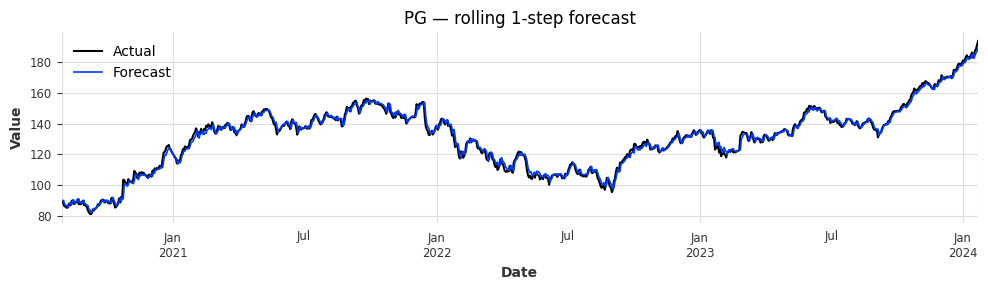

PG: MAPE=1.30%, MSE=4.6363, MAE=1.6447, R²=0.990, DirAcc=49.89%



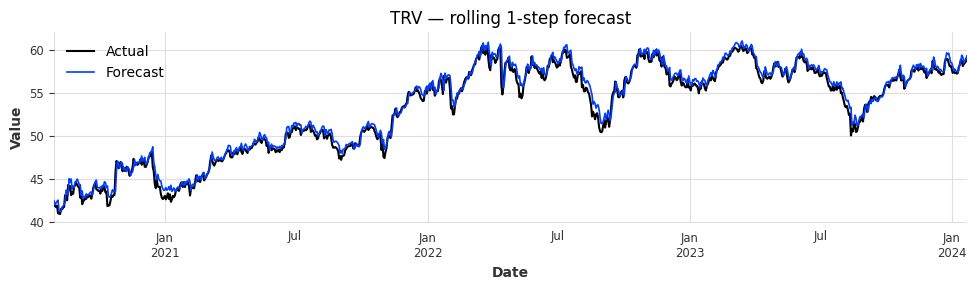

TRV: MAPE=1.05%, MSE=0.5223, MAE=0.5466, R²=0.982, DirAcc=48.90%



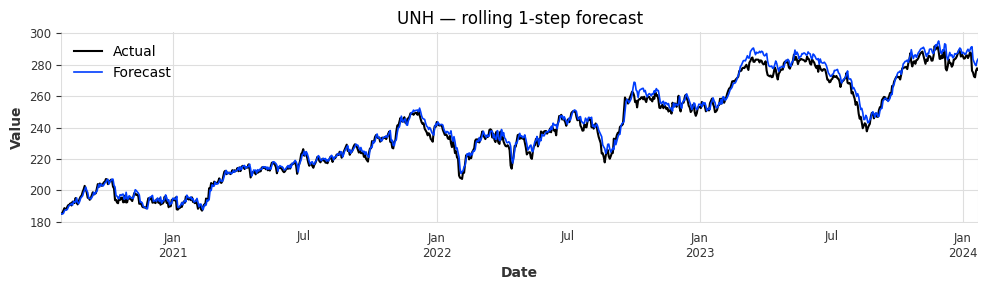

UNH: MAPE=1.12%, MSE=12.5164, MAE=2.7121, R²=0.985, DirAcc=50.55%



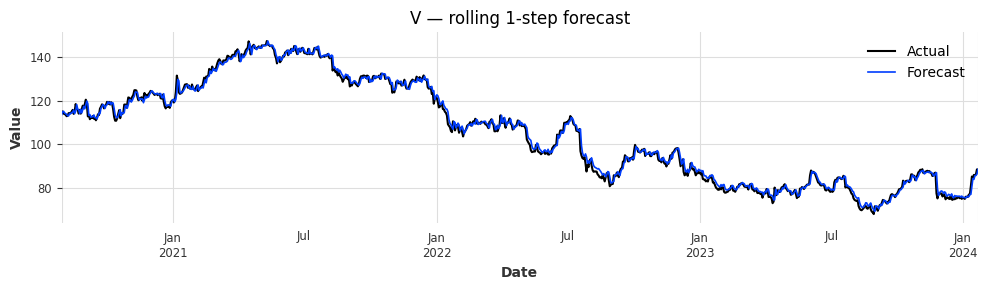

V: MAPE=1.30%, MSE=3.1102, MAE=1.3023, R²=0.994, DirAcc=46.80%



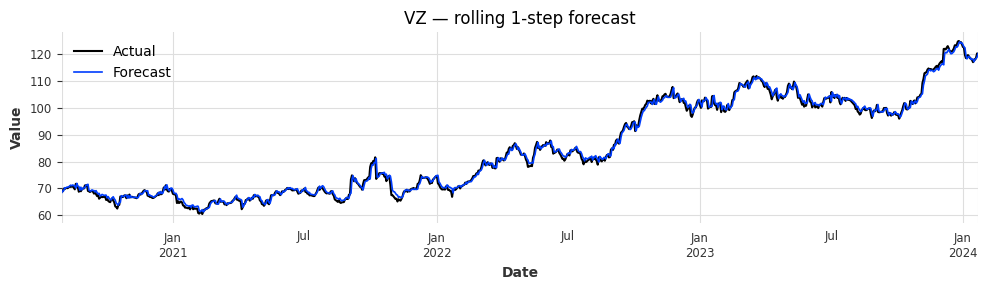

VZ: MAPE=1.05%, MSE=1.3948, MAE=0.8743, R²=0.995, DirAcc=51.10%



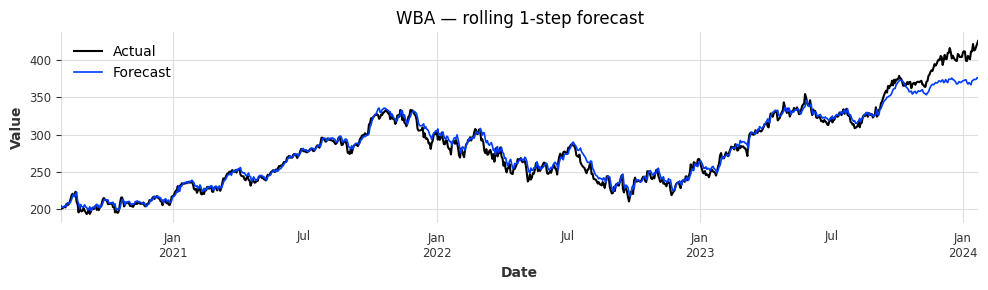

WBA: MAPE=2.16%, MSE=102.0050, MAE=6.4335, R²=0.964, DirAcc=51.43%



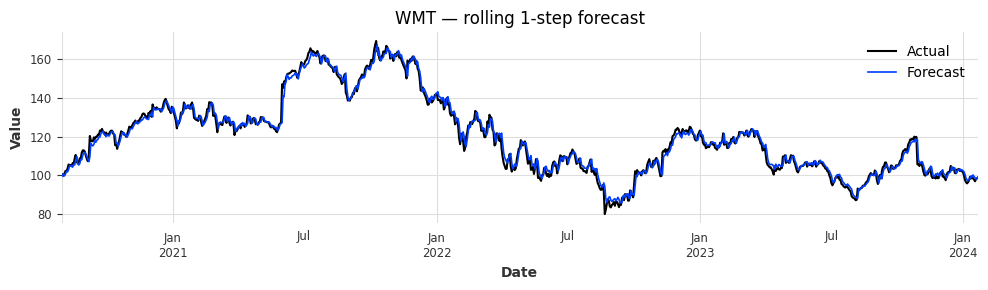

WMT: MAPE=1.60%, MSE=6.5469, MAE=1.8744, R²=0.984, DirAcc=49.34%



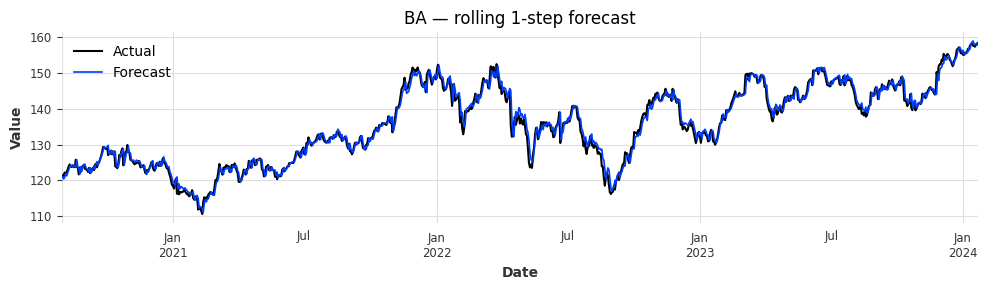

BA: MAPE=0.86%, MSE=2.5251, MAE=1.1578, R²=0.978, DirAcc=50.11%



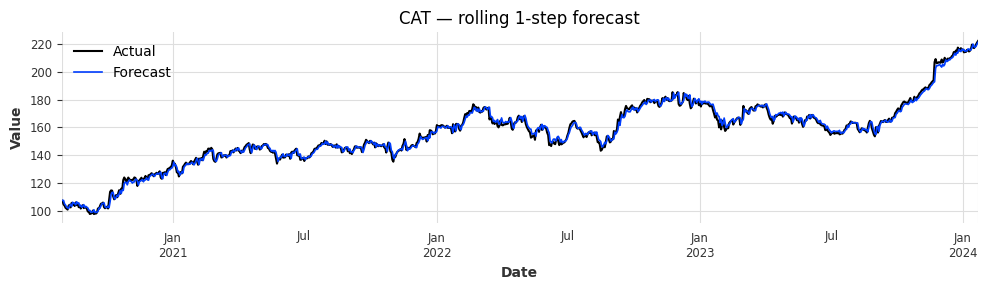

CAT: MAPE=1.14%, MSE=5.3419, MAE=1.7471, R²=0.990, DirAcc=47.57%



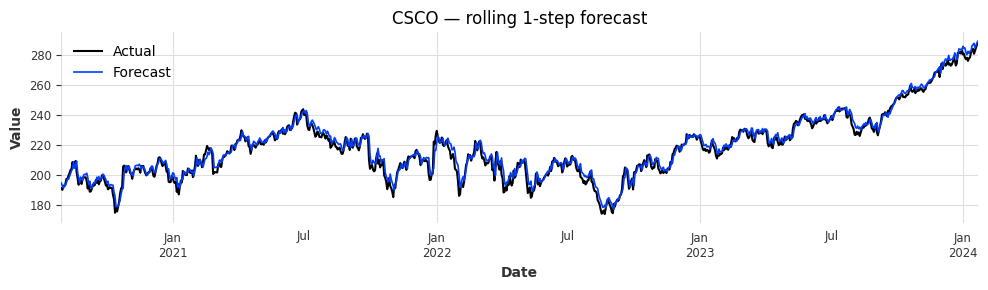

CSCO: MAPE=1.30%, MSE=13.4452, MAE=2.7666, R²=0.972, DirAcc=50.44%



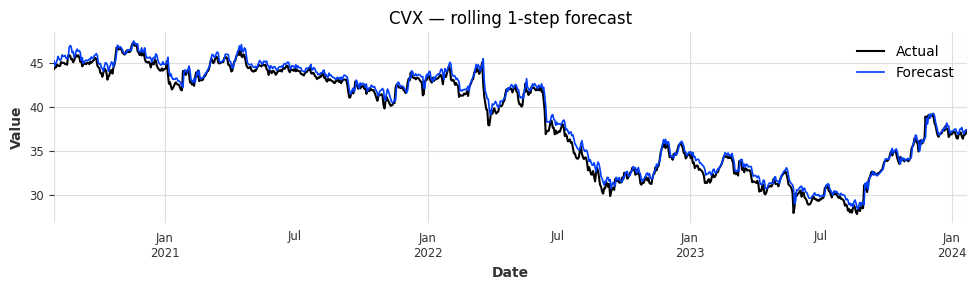

CVX: MAPE=1.46%, MSE=0.4859, MAE=0.5485, R²=0.985, DirAcc=50.11%



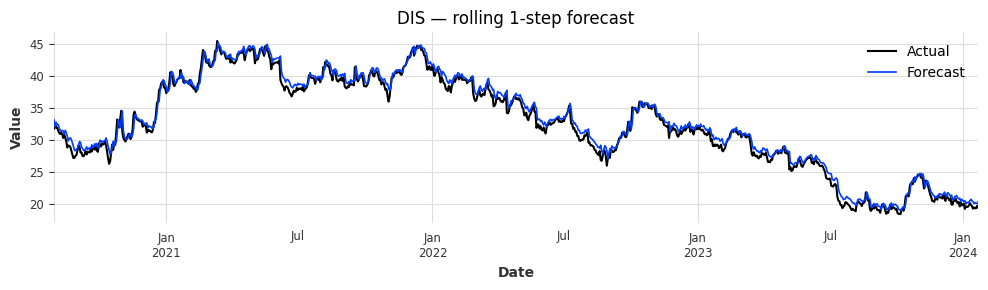

DIS: MAPE=2.33%, MSE=0.7937, MAE=0.7079, R²=0.985, DirAcc=49.78%



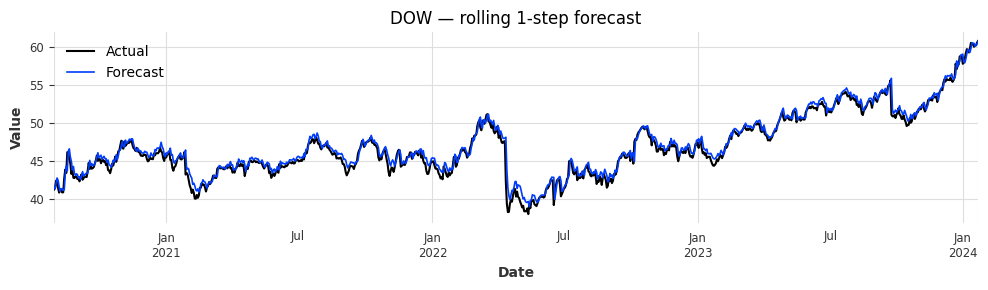

DOW: MAPE=1.20%, MSE=0.5685, MAE=0.5459, R²=0.968, DirAcc=48.90%

=== Overall rolling 1-step metrics ===
Avg MAPE:   1.53%
Avg MSE:    16.5173
Avg MAE:    2.3200
Avg R²:     0.979
Avg DirAcc: 50.33%


In [22]:
# Rolling 1-step-ahead forecasts + full metrics for each symbol
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import OrderedDict

# symbol list & any you want to skip
real_tickers = ["AMZN","AMGN","GS","HD","HON","IBM","INTC","JNJ","JPM","KO",
                "MCD","MMM","AXP","MRK","MSFT","NKE","PG","TRV","UNH","V",
                "VZ","WBA","WMT","BA","CAT","CRM","CSCO","CVX","DIS","DOW"]
# this is to account to the tickers that are added/kicked out of DJIA30 over time
exclude = {"CRM"}

# you must set this to the FIRST DAY of your TEST period
TEST_START_DATE = pd.to_datetime("2020-07-01")

# constants
WINDOW    = WINDOW_SIZE
HORIZON   = HORIZON_SIZE
n_windows = len(val_ds)
n_syms    = len(real_tickers)
w_per     = n_windows // n_syms

# prepare dicts
pred_dict   = OrderedDict()
actual_dict = OrderedDict()

model.eval()
with torch.no_grad():
    for i, sym in enumerate(real_tickers):
        if sym in exclude:
            continue

        preds = []
        trues = []
        start_idx = i * w_per
        end_idx   = start_idx + w_per

        for idx in range(start_idx, end_idx):
            x_s, x_t, x_m, y, prev, hist = val_ds[idx]
            x_s, x_t, x_m = [t.unsqueeze(0).to(device) for t in (x_s, x_t, x_m)]

            y_hat = model(x_s, x_t, x_m)[..., 3].squeeze(0).cpu().numpy()
            preds.append(y_hat[0])
            trues.append(y.squeeze(-1).numpy()[0])

        idxs = pd.date_range(
            start   = TEST_START_DATE + pd.Timedelta(days=WINDOW),
            periods = w_per,
            freq    = "B"
        )
        pred_dict[sym]   = pd.Series(preds, index=idxs)
        actual_dict[sym] = pd.Series(trues, index=idxs)

# compute metrics & plot
mape_list = []
mse_list  = []
mae_list  = []
r2_list   = []
dir_acc_list = []

for sym in pred_dict:
    pred   = pred_dict[sym]
    actual = actual_dict[sym]

    # plot rolling 1-step forecast
    plt.figure(figsize=(10,3))
    actual.plot(label="Actual", lw=1.5)
    pred.plot(label="Forecast", lw=1.2)
    plt.title(f"{sym} — rolling 1-step forecast")
    plt.xlabel("Date"); plt.ylabel("Value")
    plt.legend(); plt.tight_layout(); plt.show()

    # metrics
    mape_val = (np.abs((actual - pred) / actual)).mean() * 100
    mse_val  = np.mean((actual - pred)**2)
    mae_val  = np.mean(np.abs(actual - pred))
    # R²: 1 - SS_res / SS_tot
    ss_res   = np.sum((actual - pred)**2)
    ss_tot   = np.sum((actual - actual.mean())**2)
    r2_val   = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan

    # directional accuracy
    a_diff   = actual.diff().dropna()
    p_diff   = pred.diff().dropna()
    common   = a_diff.index.intersection(p_diff.index)
    dir_acc  = (np.sign(a_diff.loc[common]) == np.sign(p_diff.loc[common])).mean() * 100

    # collect
    mape_list.append(mape_val)
    mse_list.append(mse_val)
    mae_list.append(mae_val)
    r2_list.append(r2_val)
    dir_acc_list.append(dir_acc)

    # print per-symbol
    print(f"{sym}: "
          f"MAPE={mape_val:.2f}%, "
          f"MSE={mse_val:.4f}, "
          f"MAE={mae_val:.4f}, "
          f"R²={r2_val:.3f}, "
          f"DirAcc={dir_acc:.2f}%\n")

# overall stats
print("=== Overall rolling 1-step metrics ===")
print(f"Avg MAPE:   {np.mean(mape_list):.2f}%")
print(f"Avg MSE:    {np.mean(mse_list):.4f}")
print(f"Avg MAE:    {np.mean(mae_list):.4f}")
print(f"Avg R²:     {np.nanmean(r2_list):.3f}")
print(f"Avg DirAcc: {np.mean(dir_acc_list):.2f}%")
